# CarbonCo2 2015–2026 — Combined EDA and Data Preprocessing

This notebook combines the 2015–2024, 2025, and 2026 fuel-consumption datasets into one 2015–2026 dataset, while keeping the original EDA and preprocessing flow. Time-related analysis is added using the existing **Model Year** field.

# CO2 Emission by Vehicles

## <b><font color='red'> Business Objective </font></b>
- ##### The fundamental goal here is to model the CO2 emissions as a function of several car engines features.

## <b><font color='red'> Data Set Details </font></b>

#### The file contains the data for this example. Here the number of variables (columns) is 12, and the number of instances (rows) is 7385. In that way, this problem has the 12 following variables:
- ##### make, car brand under study.
- ##### model, the specific model of the car.
- ##### vehicle_class, car body type of the car.
- ##### engine_size, size of the car engine, in Litres.
- ##### cylinders, number of cylinders.
- ##### transmission, "A" for 'Automatic', "AM" for 'Automated manual', "AS" for 'Automatic with select shift', "AV" for 'Continuously variable', "M" for 'Manual'.
- ##### fuel_type, "X" for 'Regular gasoline', "Z" for 'Premium gasoline', "D" for 'Diesel', "E" for 'Ethanol (E85)', "N" for 'Natural gas'.
- ##### fuel_consumption_city, City fuel consumption ratings, in litres per 100 kilometres.
- ##### fuel_consumption_hwy, Highway fuel consumption ratings, in litres per 100 kilometres.
- ##### fuel_consumption_comb(l/100km), the combined fuel consumption rating (55% city, 45% highway), in L/100 km.
- ##### fuel_consumption_comb(mpg), the combined fuel consumption rating (55% city, 45% highway), in miles per gallon (mpg).
- ##### co2_emissions, the tailpipe emissions of carbon dioxide for combined city and highway driving, in grams per kilometer.


### <font color='green'> Importing some important libraries </font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## <font color='green'> EDA (Exploratory Data Analysis)</font>

In [2]:
# ============================================================
# DATA COLLECTION: COMBINE 2015-2024 + 2025 + 2026 DATASETS
# ============================================================
import os
import pandas as pd

source_files = [
    "my2015-2024-fuel-consumption-ratings.csv",
    "my2025-fuel-consumption-ratings.csv",
    "my2026-fuel-consumption-ratings.csv"
]

def read_csv_with_fallback(path):
    for encoding in ["utf-8-sig", "cp1252", "latin1"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not read {path}")

source_dfs = []
for file in source_files:
    if not os.path.exists(file):
        raise FileNotFoundError(
            f"{file} was not found. Put the three source CSV files in the same folder as this notebook."
        )
    source_dfs.append(read_csv_with_fallback(file))

# Combine all years into one dataset
df = pd.concat(source_dfs, ignore_index=True)

# Keep the original notebook naming convention
df.rename(columns={
    "Model year": "Model Year",
    "Vehicle class": "Vehicle Class",
    "Engine size (L)": "Engine Size(L)",
    "Fuel type": "Fuel Type",
    "City (L/100 km)": "Fuel Consumption City (L/100 km)",
    "Highway (L/100 km)": "Fuel Consumption Hwy (L/100 km)",
    "Combined (L/100 km)": "Fuel Consumption Comb (L/100 km)",
    "Combined (mpg)": "Fuel Consumption Comb (mpg)",
    "CO2 emissions (g/km)": "CO2 Emissions(g/km)",
    "CO2 rating": "CO2 Rating",
    "Smog rating": "Smog Rating"
}, inplace=True)

print("Combined 2015-2026 dataset shape:", df.shape)
print("Year range:", df["Model Year"].min(), "to", df["Model Year"].max())
print("Rows by year:")
print(df["Model Year"].value_counts().sort_index())

# Save the combined source dataset with the requested name
df.to_csv("CarbonCo2-2015-2026.csv", index=False)
print("\nSaved: CarbonCo2-2015-2026.csv")


Combined 2015-2026 dataset shape: (11367, 15)
Year range: 2015 to 2026
Rows by year:
Model Year
2015    1128
2016    1106
2017    1058
2018    1083
2019    1056
2020     975
2021     970
2022     976
2023     919
2024     789
2025     701
2026     606
Name: count, dtype: int64

Saved: CarbonCo2-2015-2026.csv


In [3]:
#check first 10 records
df.head(10)

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),CO2 Rating,Smog Rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN
5,2015,Acura,RLX,Mid-size,3.5,6,AS6,Z,11.9,7.7,10.0,28,230,NaN,NaN
6,2015,Acura,RLX Hybrid,Mid-size,3.5,6,AM7,Z,8.0,7.5,7.7,37,177,NaN,NaN
7,2015,Acura,TLX,Compact,2.4,4,AM8,Z,9.6,6.6,8.3,34,191,NaN,NaN
8,2015,Acura,TLX,Compact,3.5,6,AS9,Z,11.2,6.9,9.2,31,212,NaN,NaN
9,2015,Acura,TLX SH-AWD,Compact,3.5,6,AS9,Z,11.2,7.5,9.6,29,221,NaN,NaN


In [4]:
#check last 10 records
df.tail()

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),CO2 Rating,Smog Rating
11362,2026,Volvo,V60 CC B5 AWD,Station wagon: Small,2.0,4,AS8,Z,10.1,7.6,8.9,32,210,5.0,4.0
11363,2026,Volvo,V90 CC B6 AWD,Station wagon: Mid-size,2.0,4,AS8,Z,10.4,8.0,9.3,30,219,5.0,6.0
11364,2026,Volvo,XC40 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.1,7.8,9.1,31,213,5.0,4.0
11365,2026,Volvo,XC60 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.0,7.8,9.0,31,212,5.0,6.0
11366,2026,Volvo,XC90 B6 AWD,Sport utility vehicle: Standard,2.0,4,AS8,Z,11.5,9.0,10.4,27,244,5.0,6.0


In [5]:
#checking the null values
df.isnull().sum()

Model Year                             0
Make                                   0
Model                                  0
Vehicle Class                          0
Engine Size(L)                         0
Cylinders                              0
Transmission                           0
Fuel Type                              0
Fuel Consumption City (L/100 km)       0
Fuel Consumption Hwy (L/100 km)        0
Fuel Consumption Comb (L/100 km)       0
Fuel Consumption Comb (mpg)            0
CO2 Emissions(g/km)                    0
CO2 Rating                          1128
Smog Rating                         2234
dtype: int64

##### We can say there is no null values is present in out data set.

In [6]:
# collecting the information about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11367 entries, 0 to 11366
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Model Year                        11367 non-null  int64  
 1   Make                              11367 non-null  object 
 2   Model                             11367 non-null  object 
 3   Vehicle Class                     11367 non-null  object 
 4   Engine Size(L)                    11367 non-null  float64
 5   Cylinders                         11367 non-null  int64  
 6   Transmission                      11367 non-null  object 
 7   Fuel Type                         11367 non-null  object 
 8   Fuel Consumption City (L/100 km)  11367 non-null  float64
 9   Fuel Consumption Hwy (L/100 km)   11367 non-null  float64
 10  Fuel Consumption Comb (L/100 km)  11367 non-null  float64
 11  Fuel Consumption Comb (mpg)       11367 non-null  int64  
 12  CO2 

In [7]:
#checking the shape of the data set
df.shape

(11367, 15)

## <font color='red'>Time-Related EDA (2015–2026)</font>

The existing EDA is kept unchanged. The following cells only add analysis using **Model Year** so that the combined 2015–2026 data can be evaluated over time.


In [8]:
# Year coverage and number of records in each year
year_summary = (
    df.groupby("Model Year")
      .agg(
          Records=("Model Year", "size"),
          Average_CO2=("CO2 Emissions(g/km)", "mean"),
          Median_CO2=("CO2 Emissions(g/km)", "median"),
          Average_Combined_Fuel=("Fuel Consumption Comb (L/100 km)", "mean")
      )
      .reset_index()
      .sort_values("Model Year")
)

year_summary


,Model Year,Records,Average_CO2,Median_CO2,Average_Combined_Fuel
0,2015,1128,246.879433,239.0,10.982181
1,2016,1106,248.079566,245.0,10.812568
2,2017,1058,249.931947,242.0,10.866257
3,2018,1083,250.047091,246.0,10.846353
4,2019,1056,251.294508,248.0,10.868845
5,2020,975,254.800000,252.0,10.969231
6,2021,970,259.657732,256.0,11.103711
7,2022,976,260.485656,258.0,11.146516
8,2023,919,260.413493,261.0,11.193580
9,2024,789,259.863118,261.0,11.099113


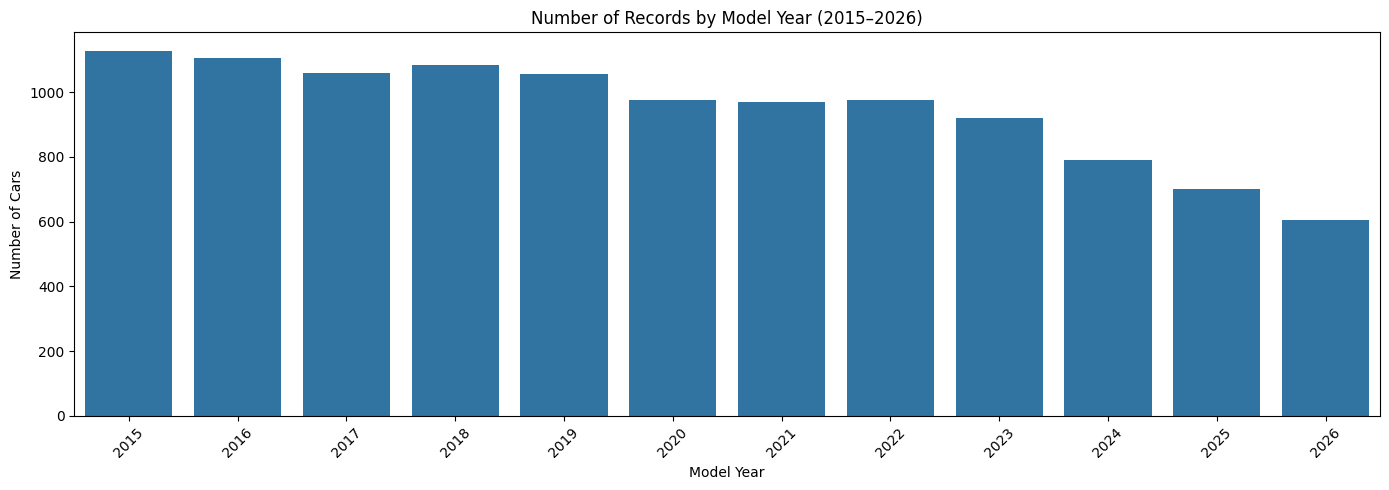

In [9]:
# Number of vehicles available in each model year
plt.figure(figsize=(14, 5))
sns.barplot(data=year_summary, x="Model Year", y="Records", color="C0")
plt.title("Number of Records by Model Year (2015–2026)")
plt.xlabel("Model Year")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


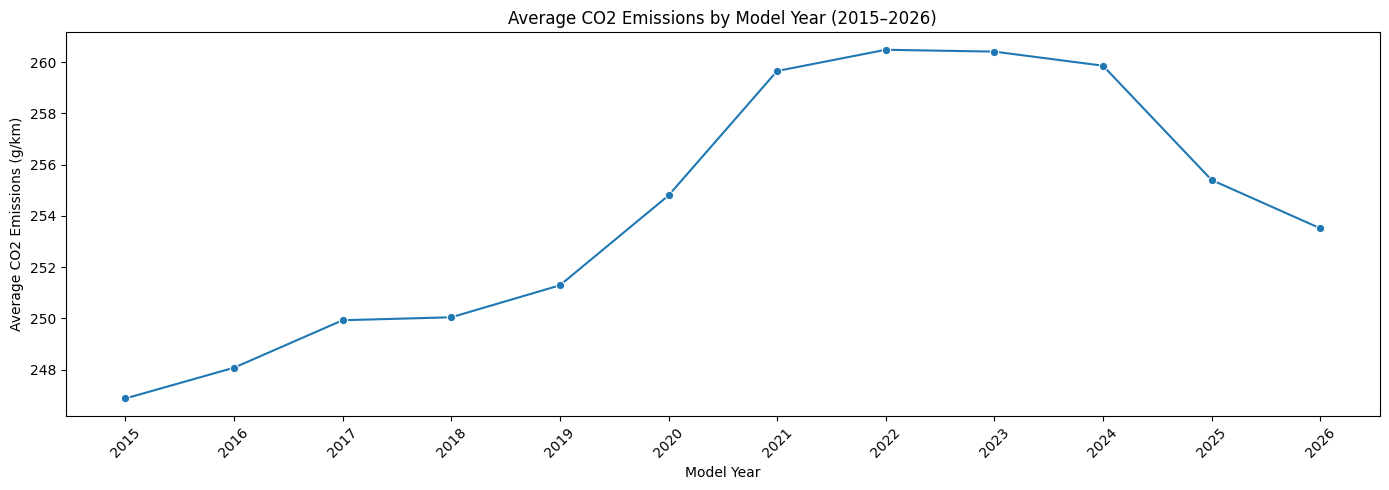

In [10]:
# Average CO2 emissions by model year
plt.figure(figsize=(14, 5))
sns.lineplot(data=year_summary, x="Model Year", y="Average_CO2", marker="o")
plt.title("Average CO2 Emissions by Model Year (2015–2026)")
plt.xlabel("Model Year")
plt.ylabel("Average CO2 Emissions (g/km)")
plt.xticks(year_summary["Model Year"], rotation=45)
plt.tight_layout()
plt.show()


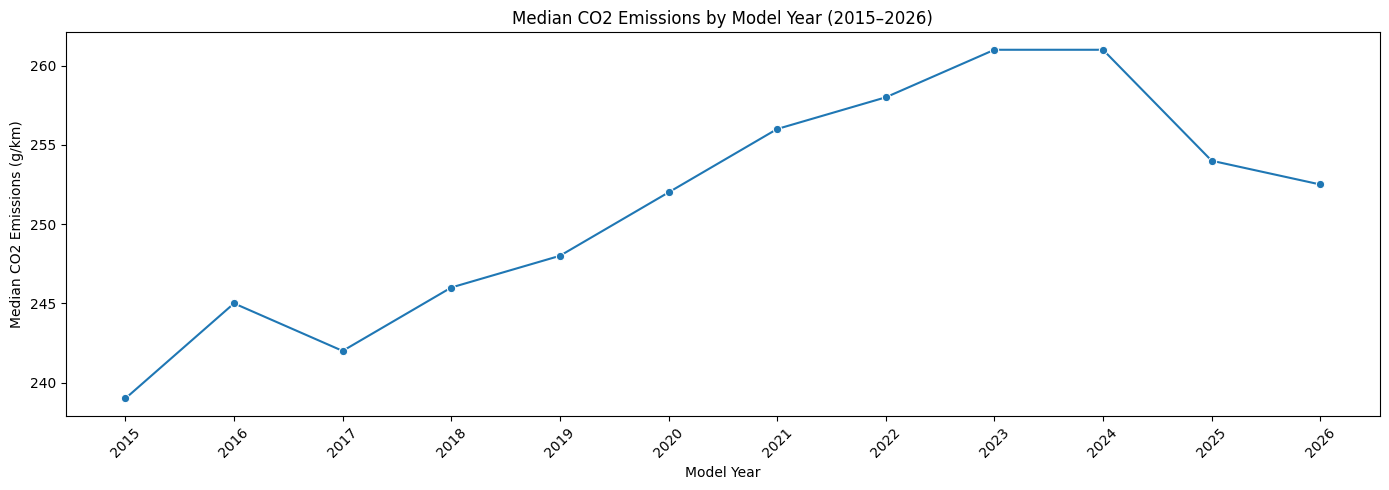

In [11]:
# Median CO2 emissions by model year
plt.figure(figsize=(14, 5))
sns.lineplot(data=year_summary, x="Model Year", y="Median_CO2", marker="o")
plt.title("Median CO2 Emissions by Model Year (2015–2026)")
plt.xlabel("Model Year")
plt.ylabel("Median CO2 Emissions (g/km)")
plt.xticks(year_summary["Model Year"], rotation=45)
plt.tight_layout()
plt.show()


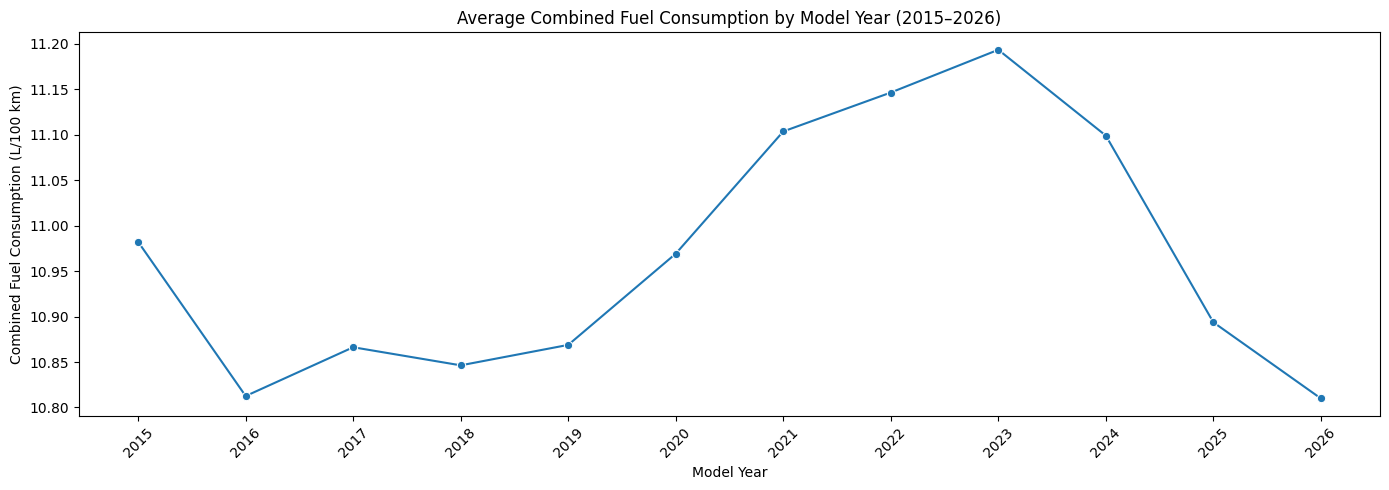

In [12]:
# Average combined fuel consumption by model year
plt.figure(figsize=(14, 5))
sns.lineplot(
    data=year_summary,
    x="Model Year",
    y="Average_Combined_Fuel",
    marker="o"
)
plt.title("Average Combined Fuel Consumption by Model Year (2015–2026)")
plt.xlabel("Model Year")
plt.ylabel("Combined Fuel Consumption (L/100 km)")
plt.xticks(year_summary["Model Year"], rotation=45)
plt.tight_layout()
plt.show()


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Model Year,11367.0,2019.957421,3.328136,2015.0,2017.0,2020.0,2023.0,2026.0
Engine Size(L),11367.0,3.126885,1.325826,0.9,2.0,3.0,3.6,8.4
Cylinders,11367.0,5.594264,1.869835,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),11367.0,12.440292,3.408031,4.0,10.1,12.1,14.5,30.7
Fuel Consumption Hwy (L/100 km),11367.0,9.162576,2.188278,3.9,7.6,8.9,10.4,20.9
Fuel Consumption Comb (L/100 km),11367.0,10.965356,2.811582,4.0,9.0,10.7,12.7,26.1
Fuel Consumption Comb (mpg),11367.0,27.500572,7.427174,11.0,22.0,26.0,31.0,71.0
CO2 Emissions(g/km),11367.0,253.805402,61.116526,94.0,209.0,250.0,293.0,608.0
CO2 Rating,10239.0,4.602598,1.546946,1.0,4.0,5.0,5.0,10.0
Smog Rating,9133.0,4.834775,1.728370,1.0,3.0,5.0,6.0,8.0


In [14]:
# checking duplicate values
df.duplicated().sum()

np.int64(0)

In [15]:
# droping all the duplicate values
df.drop_duplicates(inplace=True)

In [16]:
len(df)

11367

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Model Year,11367.0,2019.957421,3.328136,2015.0,2017.0,2020.0,2023.0,2026.0
Engine Size(L),11367.0,3.126885,1.325826,0.9,2.0,3.0,3.6,8.4
Cylinders,11367.0,5.594264,1.869835,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),11367.0,12.440292,3.408031,4.0,10.1,12.1,14.5,30.7
Fuel Consumption Hwy (L/100 km),11367.0,9.162576,2.188278,3.9,7.6,8.9,10.4,20.9
Fuel Consumption Comb (L/100 km),11367.0,10.965356,2.811582,4.0,9.0,10.7,12.7,26.1
Fuel Consumption Comb (mpg),11367.0,27.500572,7.427174,11.0,22.0,26.0,31.0,71.0
CO2 Emissions(g/km),11367.0,253.805402,61.116526,94.0,209.0,250.0,293.0,608.0
CO2 Rating,10239.0,4.602598,1.546946,1.0,4.0,5.0,5.0,10.0
Smog Rating,9133.0,4.834775,1.728370,1.0,3.0,5.0,6.0,8.0


In [18]:
df.reset_index(drop=True, inplace=True)

In [19]:
df.head()

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),CO2 Rating,Smog Rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN


## <font color='red'>Visualization</font>

### <font color='green'> Brands of Cars </font>

In [20]:
print("We have total",len(df['Make'].unique()),"Car Companies Data")
df_brand = df['Make'].value_counts().reset_index().rename(columns={'count':'Count'})
df_brand.head(20)

We have total 43 Car Companies Data


,Make,Count
0,Ford,956
1,Chevrolet,873
2,BMW,783
3,Mercedes-Benz,715
4,Porsche,705
5,Toyota,584
6,GMC,533
7,Audi,470
8,Nissan,366
9,Jeep,365


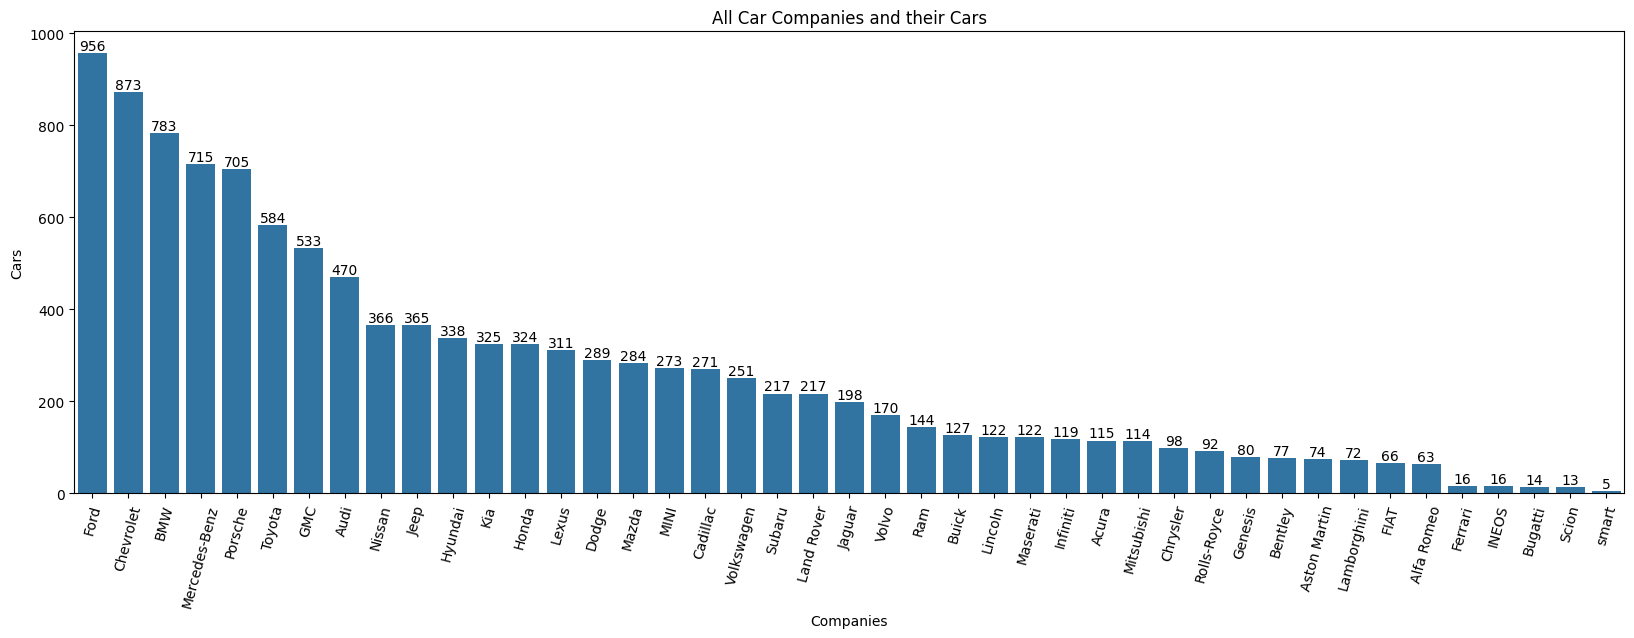

In [21]:
plt.figure(figsize=(20,6))
figure1 = sns.barplot(data=df_brand, x="Make", y="Count", color="C0")
plt.xticks(rotation = 75)
plt.title("All Car Companies and their Cars")
plt.xlabel("Companies")
plt.ylabel("Cars")
plt.bar_label(figure1.containers[0])
plt.show()

### <font color=green> Models of cars </font>

In [22]:
print("We have total",len(df['Model'].unique()),"Car Models")
df_model = df['Model'].value_counts().reset_index().rename(columns={'count':'Count'})[:25]
df_model.head(20)

We have total 2239 Car Models


,Model,Count
0,Mustang,54
1,Sierra 4WD,53
2,Silverado 4WD,53
3,Silverado,43
4,Sierra,43
5,Camaro,38
6,Elantra,36
7,F-150 FFV,36
8,Civic Sedan,33
9,F-150 4X4,33


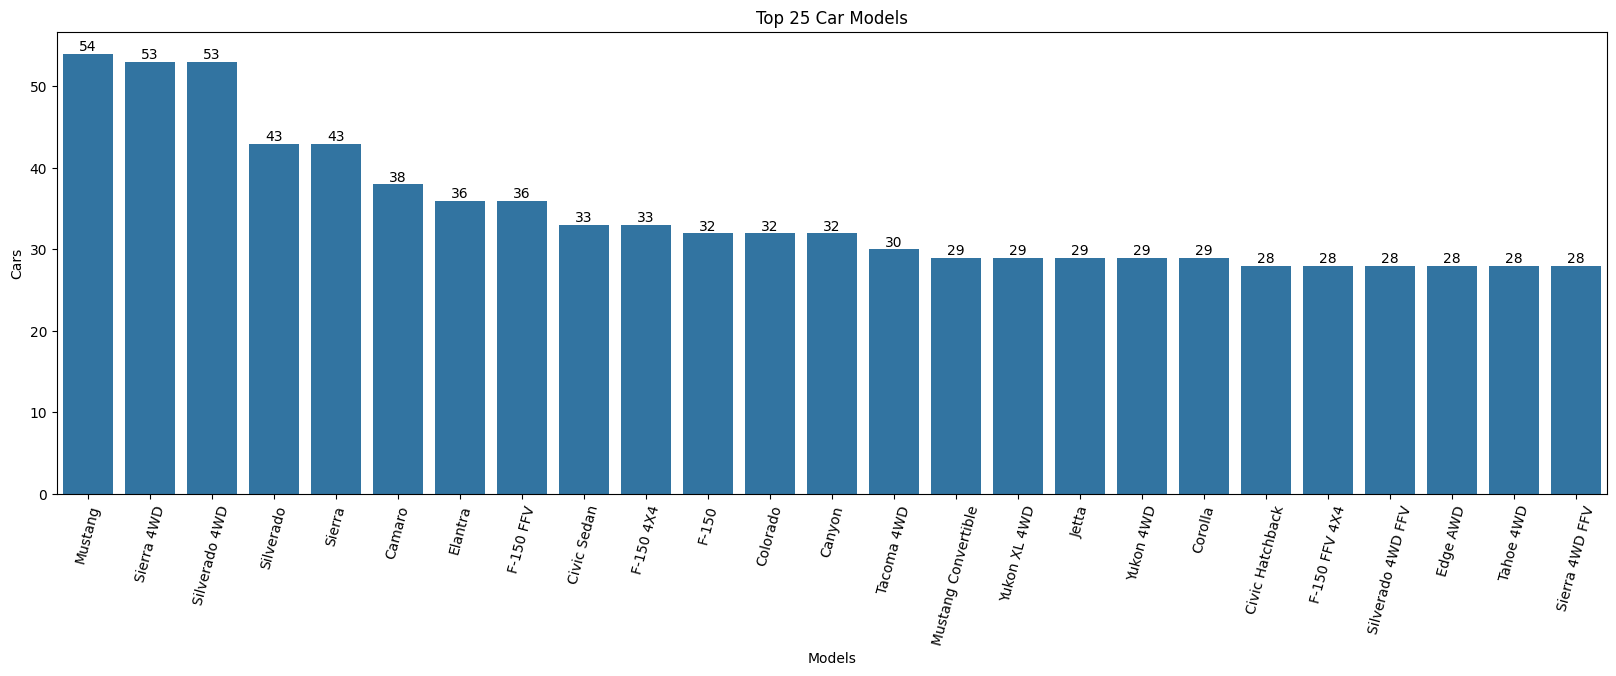

In [23]:
plt.figure(figsize=(20,6))
figure2 = sns.barplot(data=df_model, x="Model", y="Count", color="C0")
plt.xticks(rotation = 75)
plt.title("Top 25 Car Models")
plt.xlabel("Models")
plt.ylabel("Cars")
plt.bar_label(figure2.containers[0])
plt.show()

### <font color=green> Vehicle Class </font>

In [24]:
print("We have total",len(df['Vehicle Class'].unique()),"Vehicle Class")
df_vehicle_class = df['Vehicle Class'].value_counts().reset_index().rename(columns={'count':'Count'})
df_vehicle_class

We have total 15 Vehicle Class


,Vehicle Class,Count
0,Sport utility vehicle: Small,2204
1,Sport utility vehicle: Standard,1509
2,Mid-size,1508
3,Compact,1229
4,Pickup truck: Standard,1033
5,Subcompact,940
6,Full-size,837
7,Two-seater,704
8,Minicompact,504
9,Station wagon: Small,312


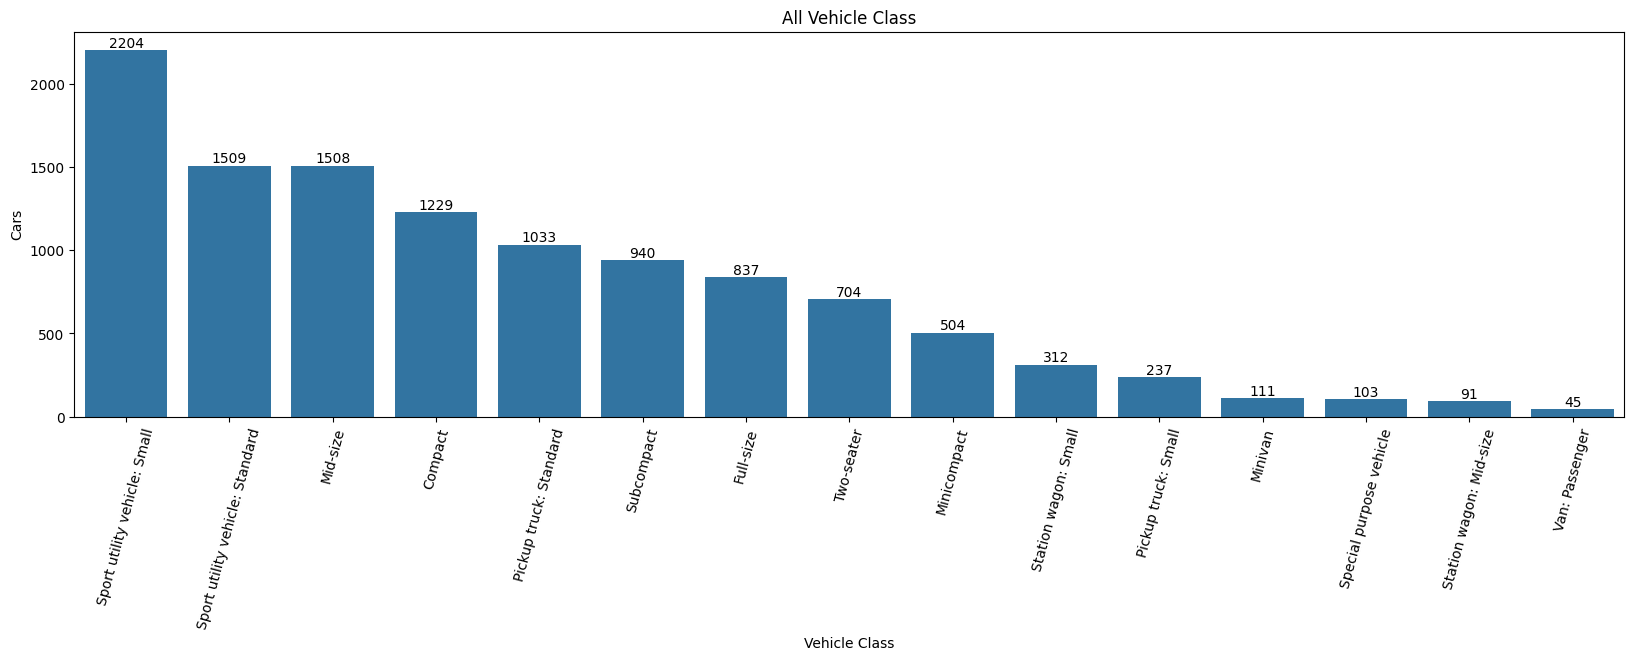

In [25]:
plt.figure(figsize=(20,5))
figure3 = sns.barplot(data=df_vehicle_class, x="Vehicle Class", y="Count", color="C0")
plt.xticks(rotation = 75)
plt.title("All Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Cars")
plt.bar_label(figure3.containers[0])
plt.show()

### <font color='green'> Engine Sizes of cars</font>

In [26]:
print("We have total",len(df['Engine Size(L)'].unique()),"Types of Engine Size")
df_engine_size = df['Engine Size(L)'].value_counts().reset_index().rename(columns={'count':'Count'})
df_engine_size.head(20)

We have total 50 Types of Engine Size


,Engine Size(L),Count
0,2.0,2472
1,3.0,1519
2,2.5,789
3,3.5,689
4,3.6,638
5,4.0,482
6,5.3,432
7,2.4,427
8,1.5,365
9,1.6,357


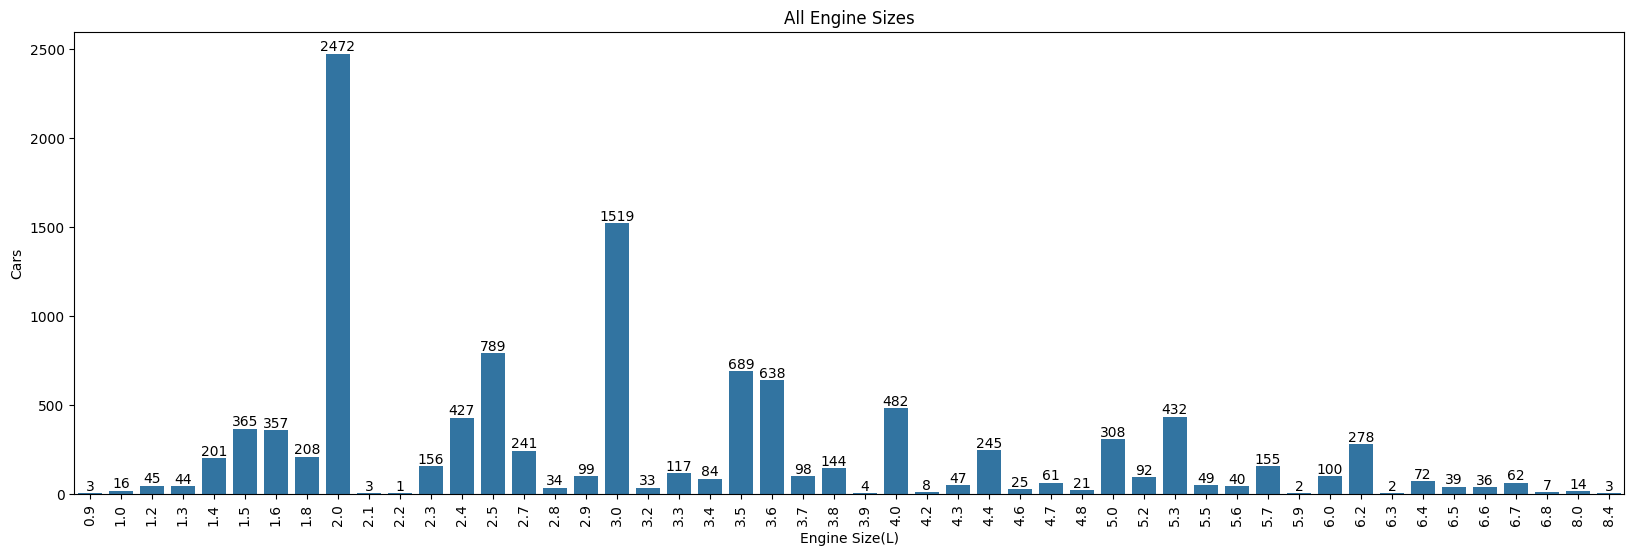

In [27]:
plt.figure(figsize=(20,6))
figure4 = sns.barplot(data=df_engine_size, x="Engine Size(L)", y="Count", color="C0")
plt.xticks(rotation = 90)
plt.title("All Engine Sizes")
plt.xlabel("Engine Size(L)")
plt.ylabel("Cars")
plt.bar_label(figure4.containers[0])
plt.show()

### <font color='green'> Cylinders </font>

In [28]:
print("We have total",len(df['Cylinders'].unique()),"Types of Cylinders")
df_cylinders = df['Cylinders'].value_counts().reset_index().rename(columns={'count':'Count'})
df_cylinders.head(20)

We have total 8 Types of Cylinders


,Cylinders,Count
0,4,5033
1,6,3649
2,8,2139
3,12,239
4,3,210
5,10,63
6,5,20
7,16,14


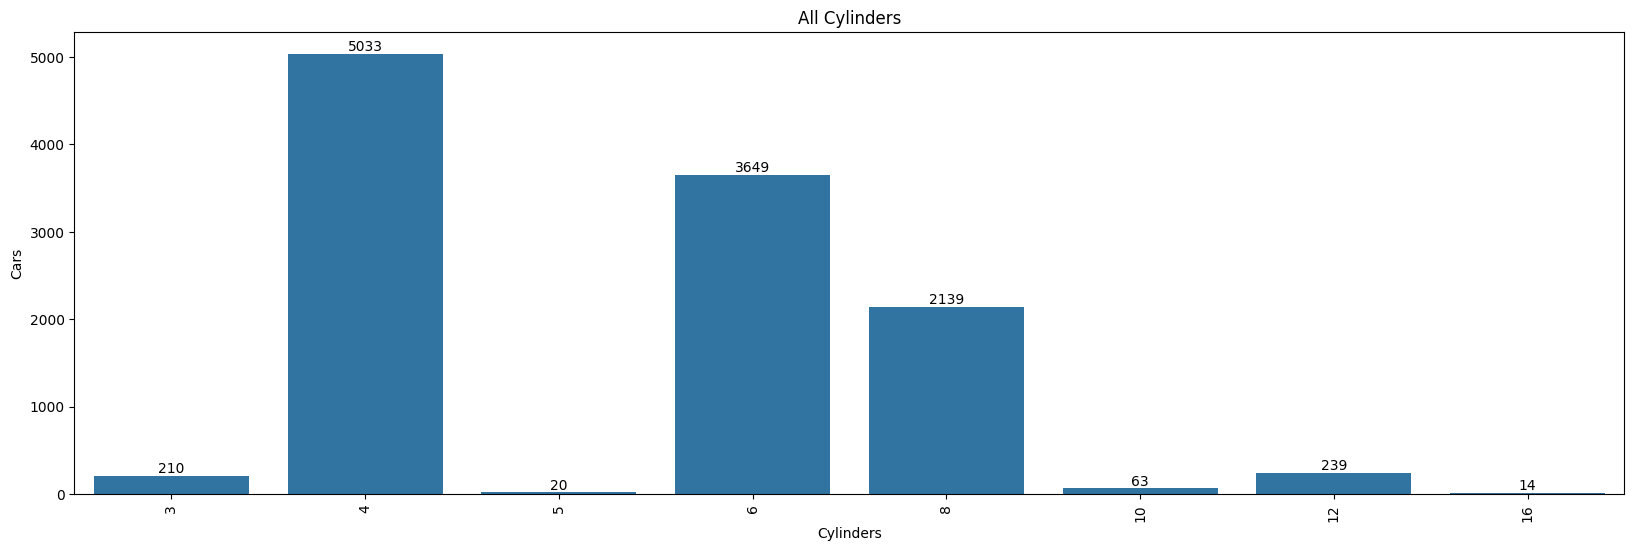

In [29]:
plt.figure(figsize=(20,6))
figure5 = sns.barplot(data=df_cylinders, x="Cylinders", y="Count", color="C0")
plt.xticks(rotation = 90)
plt.title("All Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Cars")
plt.bar_label(figure5.containers[0])
plt.show()

### <font color='green'> Transmission of Cars </font>

In [30]:
df['Transmission'].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM7', 'AM8', 'AS9', 'AM6', 'A6', 'A8',
       'AV8', 'AS8', 'AV', 'M7', 'M5', 'A9', 'A5', 'A4', 'AS7', 'AV6',
       'A7', 'AS4', 'AM5', 'AM9', 'AS10', 'A10', 'AV10', 'AV1'],
      dtype=object)

#### Here we have to map similar labels into a single label for our Transmission column.

In [31]:
df["Transmission"] = np.where(df["Transmission"].isin(["A4", "A5", "A6", "A7", "A8", "A9", "A10"]), "Automatic", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AM5", "AM6", "AM7", "AM8", "AM9"]), "Automated Manual", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AS4", "AS5", "AS6", "AS7", "AS8", "AS9", "AS10"]), "Automatic with Select Shift", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AV", "AV6", "AV7", "AV8", "AV10"]), "Continuously Variable", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["M5", "M6", "M7"]), "Manual", df["Transmission"])

In [32]:
print("We have total",len(df['Transmission'].unique()),"Transmissions")
df_transmission = df['Transmission'].value_counts().reset_index().rename(columns={'count':'Count'})
df_transmission

We have total 6 Transmissions


,Transmission,Count
0,Automatic with Select Shift,4799
1,Automatic,2803
2,Manual,1400
3,Automated Manual,1293
4,Continuously Variable,1034
5,AV1,38


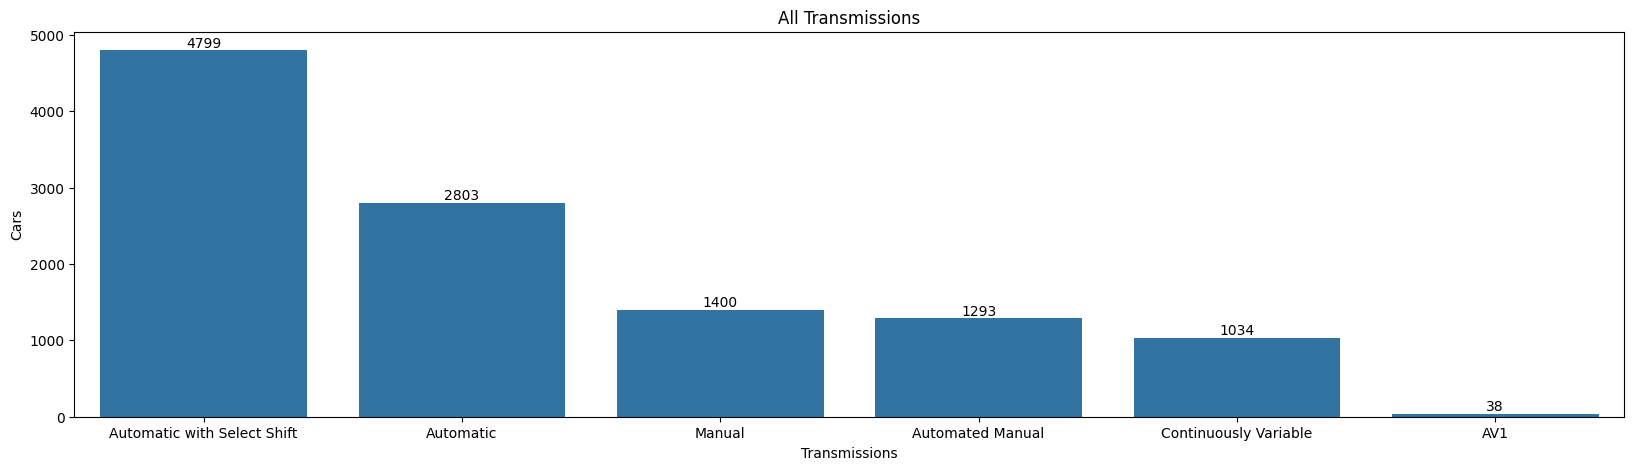

In [33]:
plt.figure(figsize=(20,5))
figure6 = sns.barplot(data=df_transmission, x="Transmission", y="Count", color="C0")
plt.title("All Transmissions")
plt.xlabel("Transmissions")
plt.ylabel("Cars")
plt.bar_label(figure6.containers[0])
plt.show()

### <font color='green'> Fuel Type of Cars </font>

In [34]:
df['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

#### Here we have to map similar labels into a single label for our Fuel Type column.

In [35]:
df["Fuel Type"] = np.where(df["Fuel Type"]=="Z", "Premium Gasoline", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="X", "Regular Gasoline", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="D", "Diesel", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="E", "Ethanol(E85)", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="N", "Natural Gas", df["Fuel Type"])

In [36]:
print("We have total",len(df['Fuel Type'].unique()),"Fuel Types")
df_fuel_type = df['Fuel Type'].value_counts().reset_index().rename(columns={'count':'Count'})
df_fuel_type

We have total 5 Fuel Types


,Fuel Type,Count
0,Premium Gasoline,5422
1,Regular Gasoline,5345
2,Ethanol(E85),334
3,Diesel,265
4,Natural Gas,1


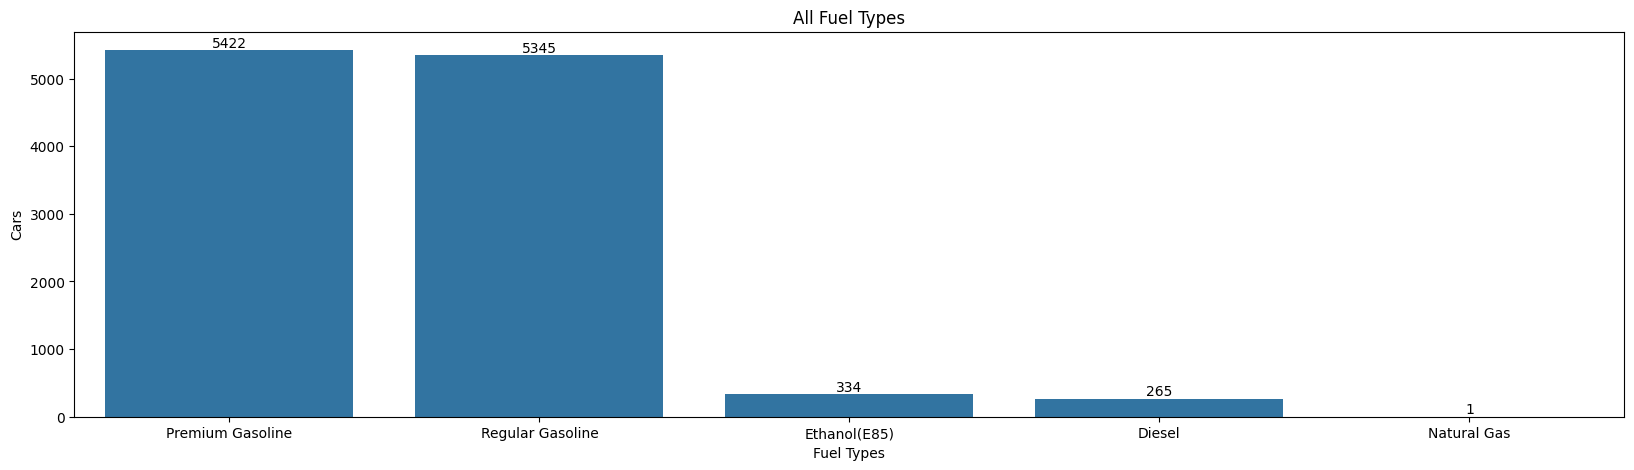

In [37]:
plt.figure(figsize=(20,5))
figure7 = sns.barplot(data=df_fuel_type, x="Fuel Type", y="Count", color="C0")
plt.title("All Fuel Types")
plt.xlabel("Fuel Types")
plt.ylabel("Cars")
plt.bar_label(figure7.containers[0])
plt.show()

### <font color='green'> Distplot </font>

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Density'>

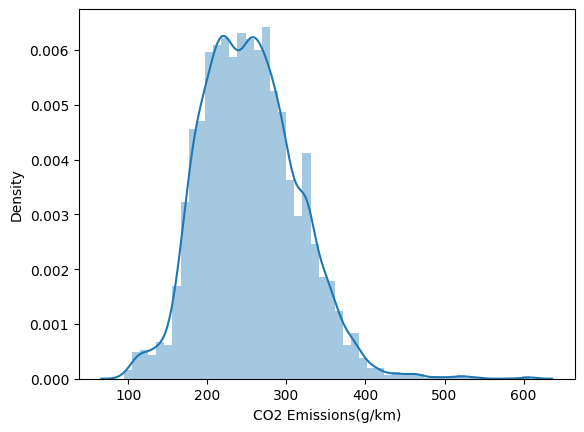

In [38]:
sns.distplot(df['CO2 Emissions(g/km)'], color='C0')

<Axes: xlabel='Cylinders', ylabel='Density'>

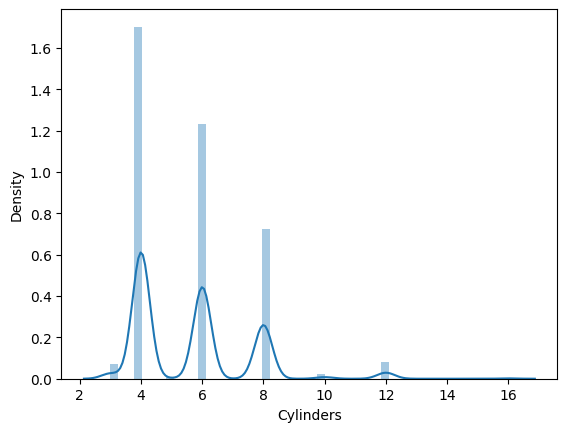

In [39]:
sns.distplot(df['Cylinders'], color='C0')

<Axes: xlabel='Engine Size(L)', ylabel='Density'>

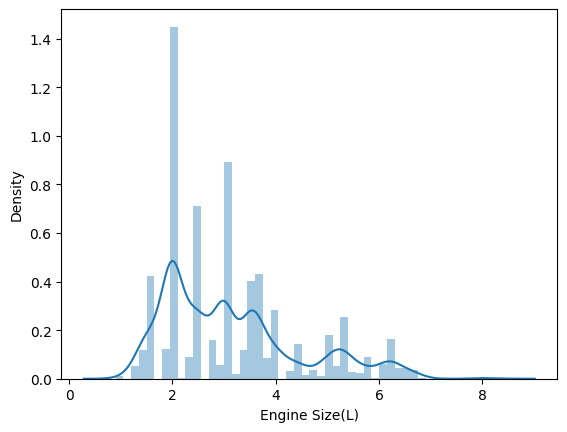

In [40]:
sns.distplot(df['Engine Size(L)'], color='C0')

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='Density'>

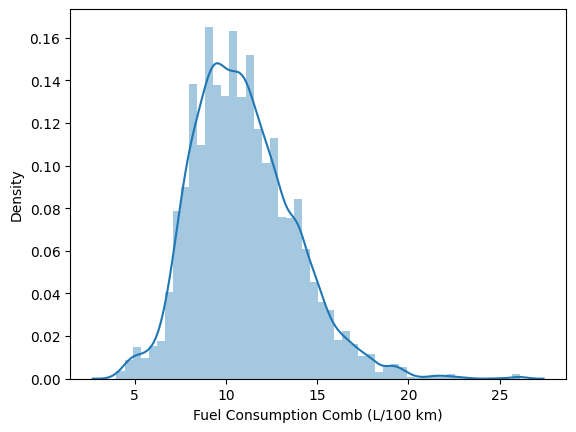

In [41]:
sns.distplot(df['Fuel Consumption Comb (L/100 km)'], color='C0')

## <font color='red'>Variation in CO2 emissions with different features.</font>

### <font color='green'> CO2 Emission with Brand </font>

In [42]:
df_co2_make = df.groupby(['Make'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

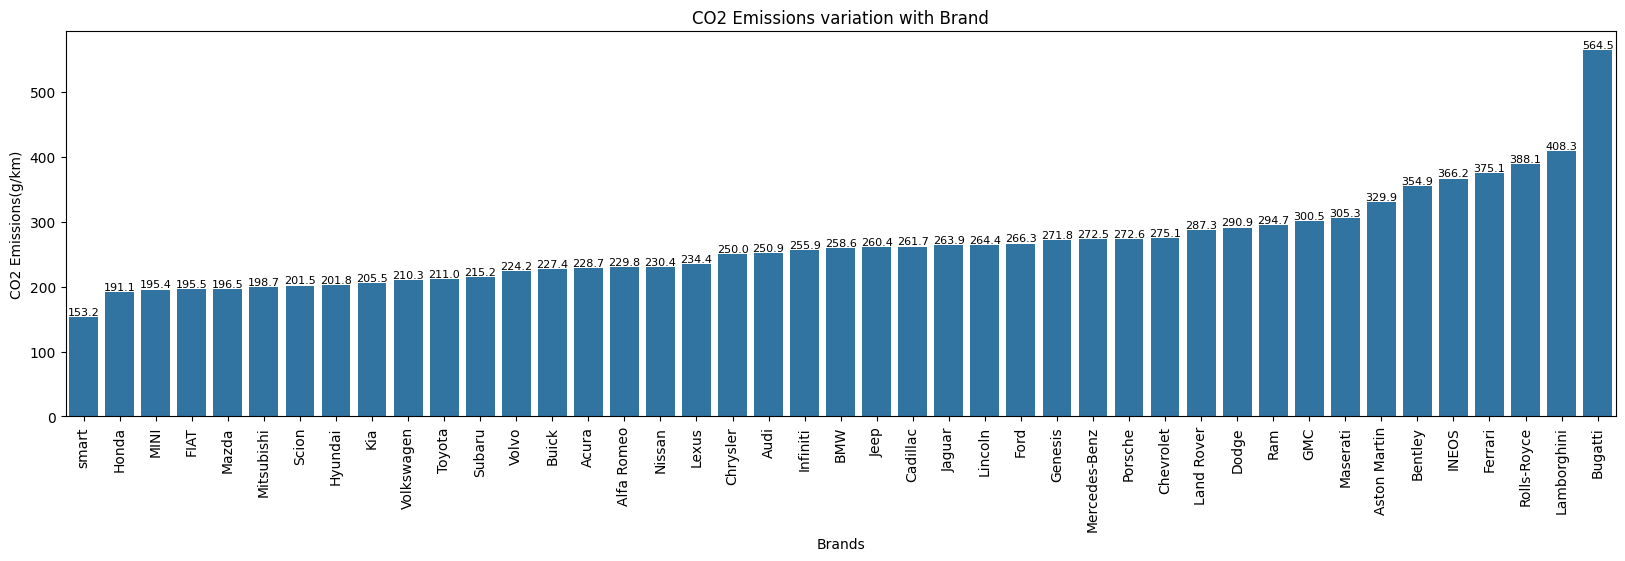

In [43]:
plt.figure(figsize=(20,5))
figure8 = sns.barplot(data=df_co2_make, x="Make", y="CO2 Emissions(g/km)", color="C0")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Brand")
plt.xlabel("Brands")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure8.containers[0], fontsize=8, fmt='%.1f')
plt.show()

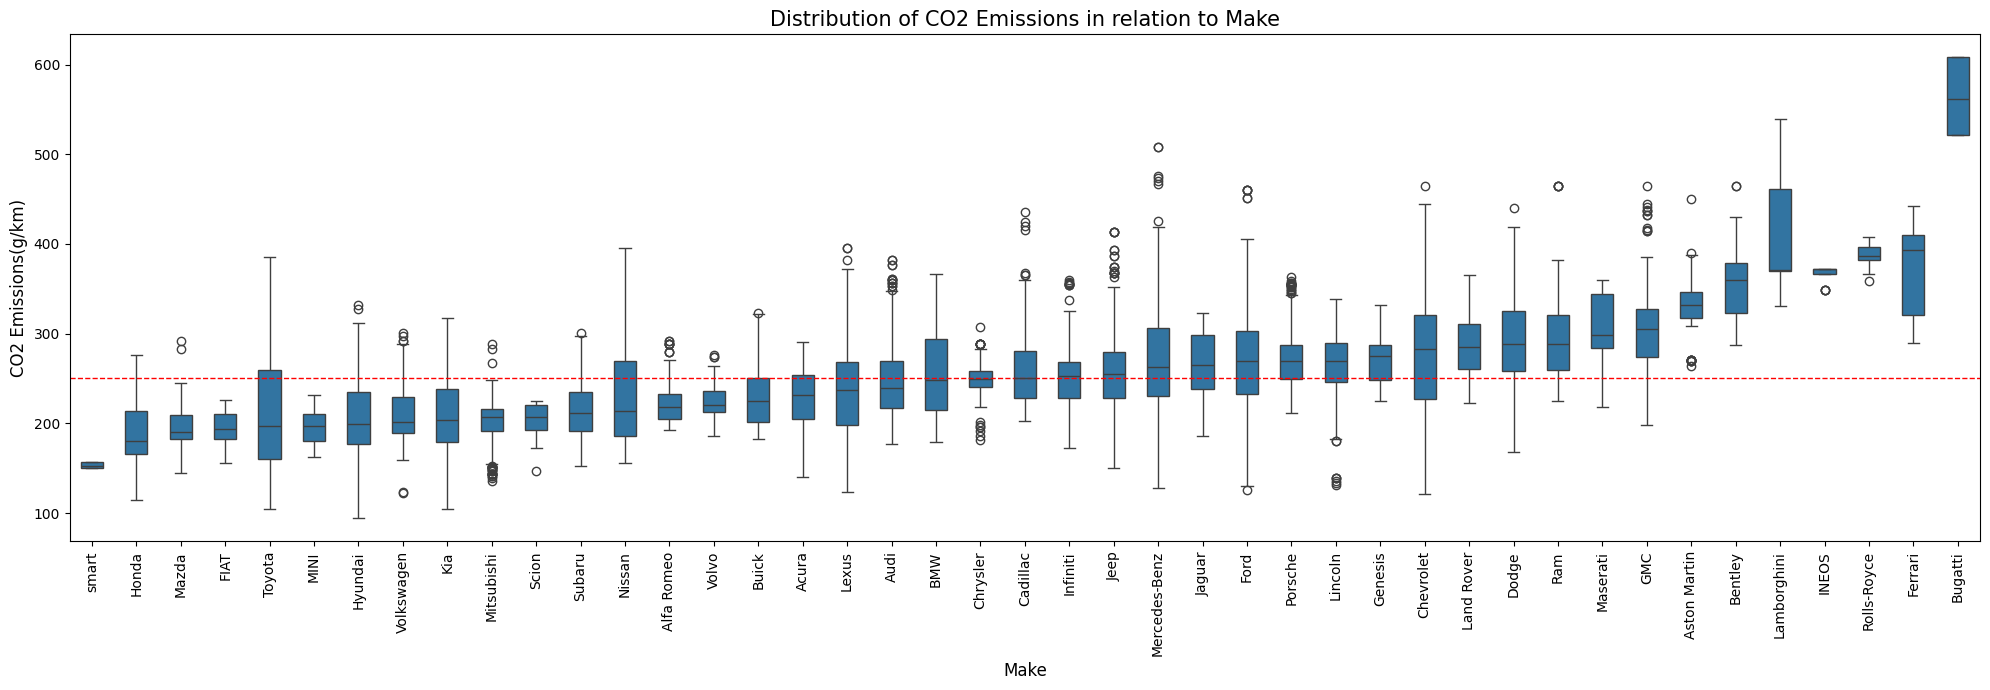

In [44]:
plt.figure(figsize=(20,7))
order = df.groupby("Make")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Make", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Make", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color='green'> CO2 Emissions variation with Vehicle Class </font>

In [45]:
df_co2_vehicle_class = df.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

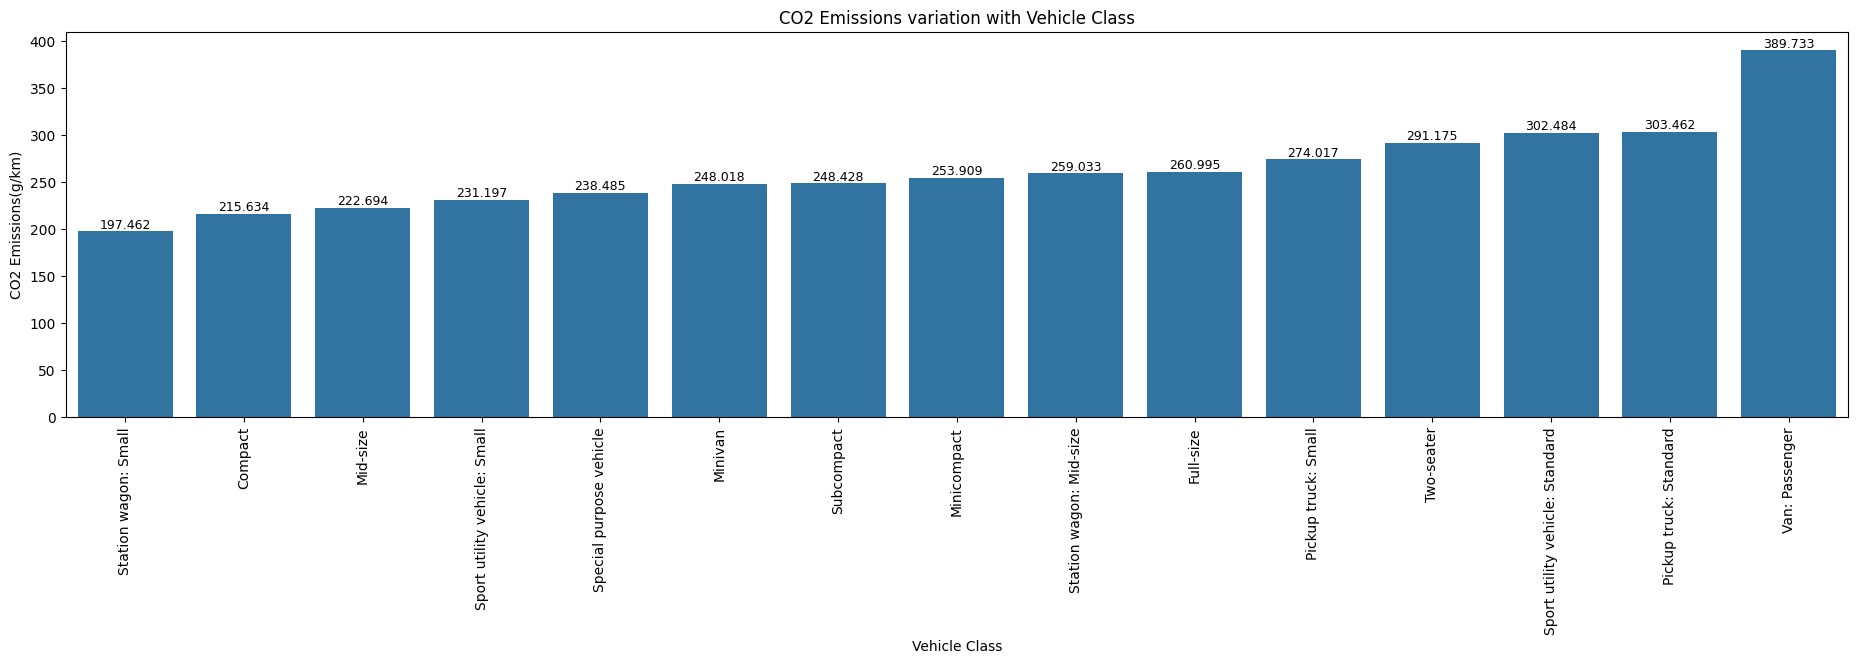

In [46]:
plt.figure(figsize=(23,5))
figure9 = sns.barplot(data=df_co2_vehicle_class, x="Vehicle Class", y="CO2 Emissions(g/km)", color="C0")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure9.containers[0], fontsize=9)
plt.show()

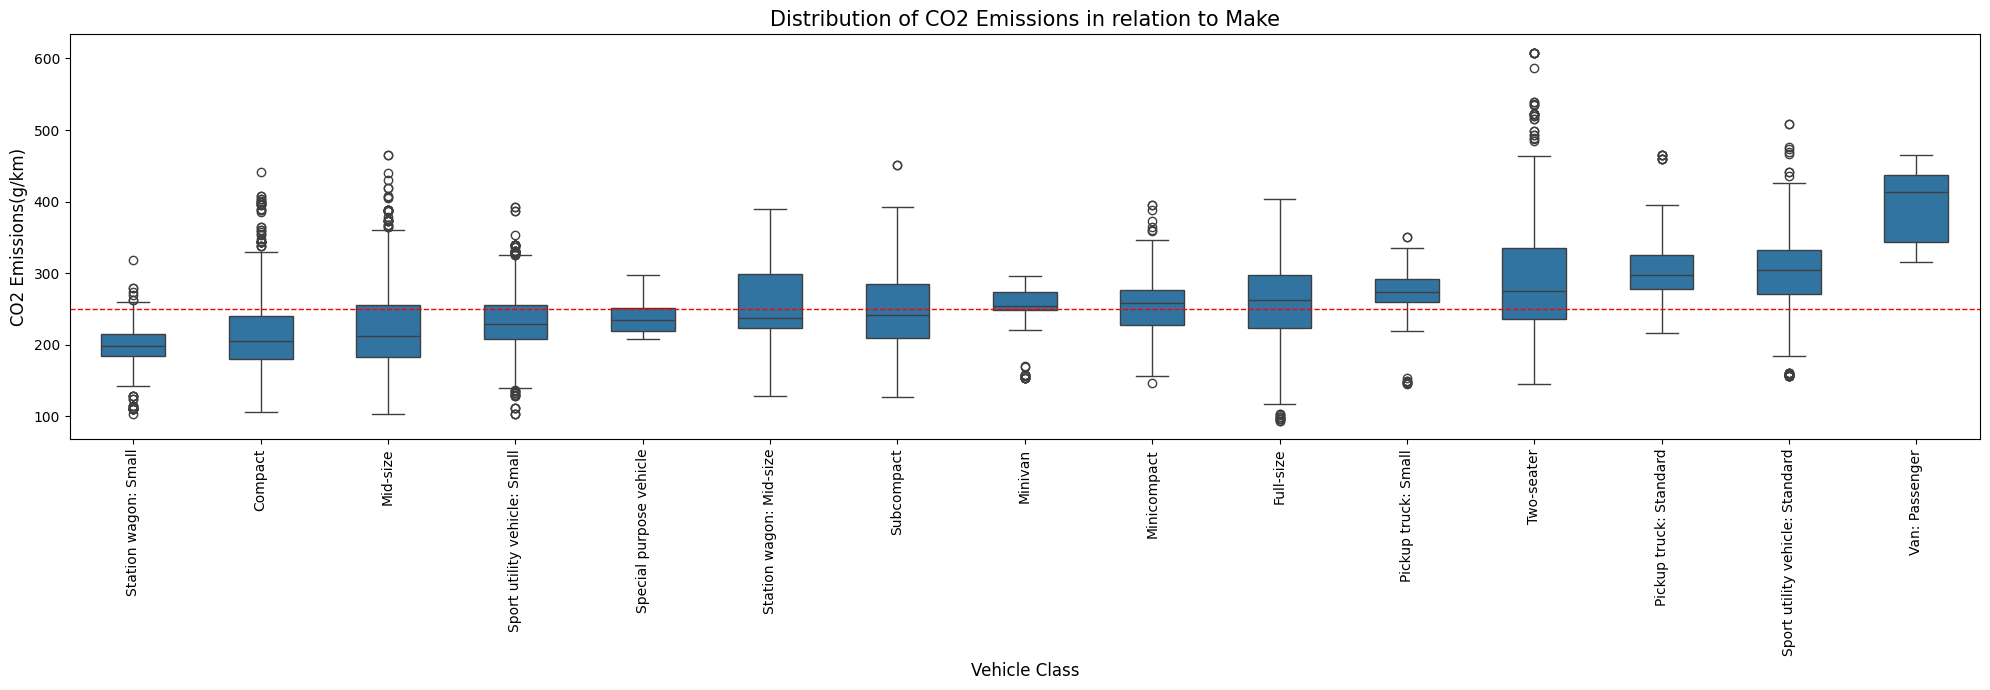

In [47]:
plt.figure(figsize=(20,7))
order = df.groupby("Vehicle Class")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Vehicle Class", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Vehicle Class", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color='green'> CO2 Emissions variation with Transmission </font>

In [48]:
df_co2_transmission = df.groupby(['Transmission'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

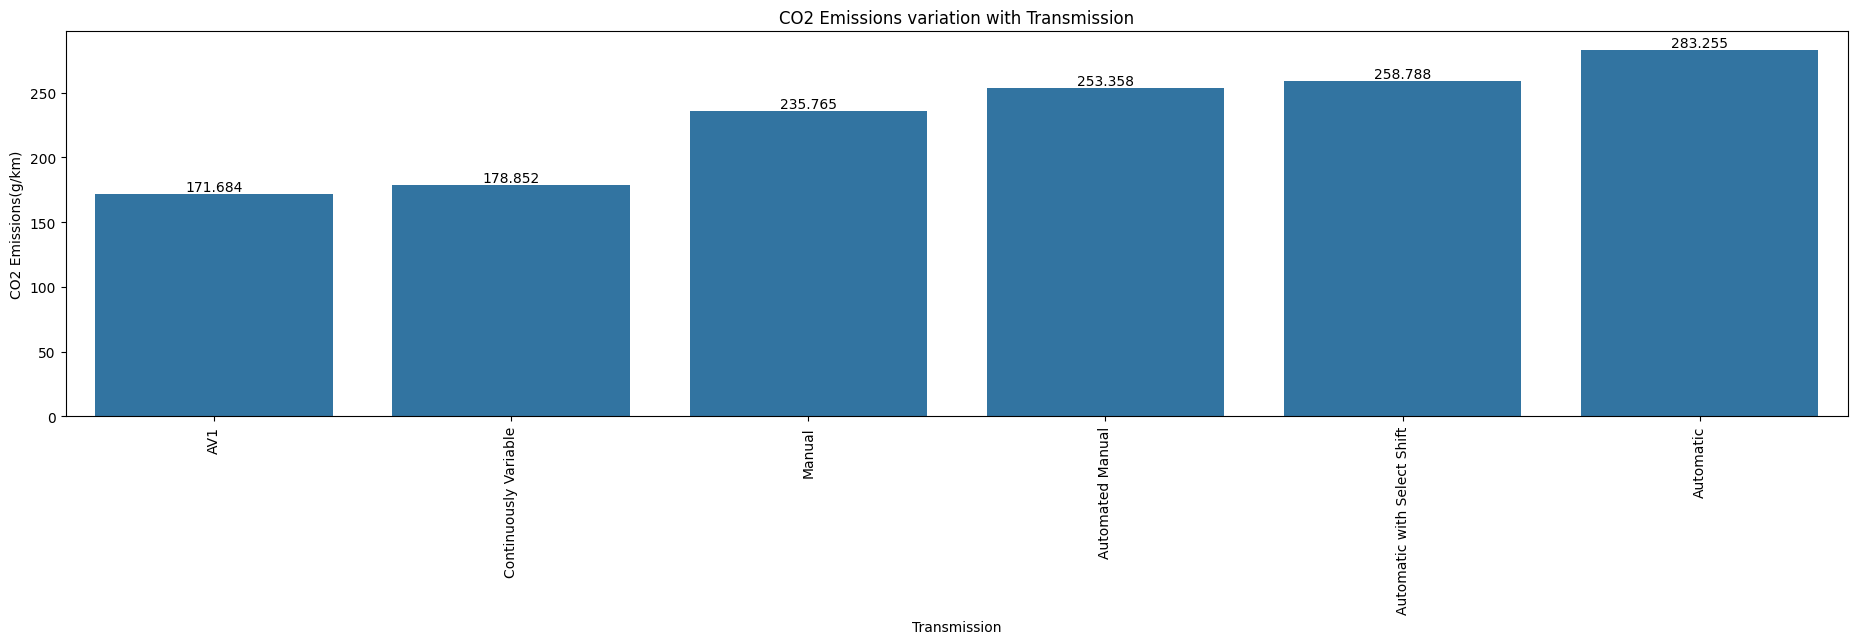

In [49]:
plt.figure(figsize=(23,5))
figure10 = sns.barplot(data=df_co2_transmission, x="Transmission", y="CO2 Emissions(g/km)", color="C0")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Transmission")
plt.xlabel("Transmission")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure10.containers[0], fontsize=10)
plt.show()

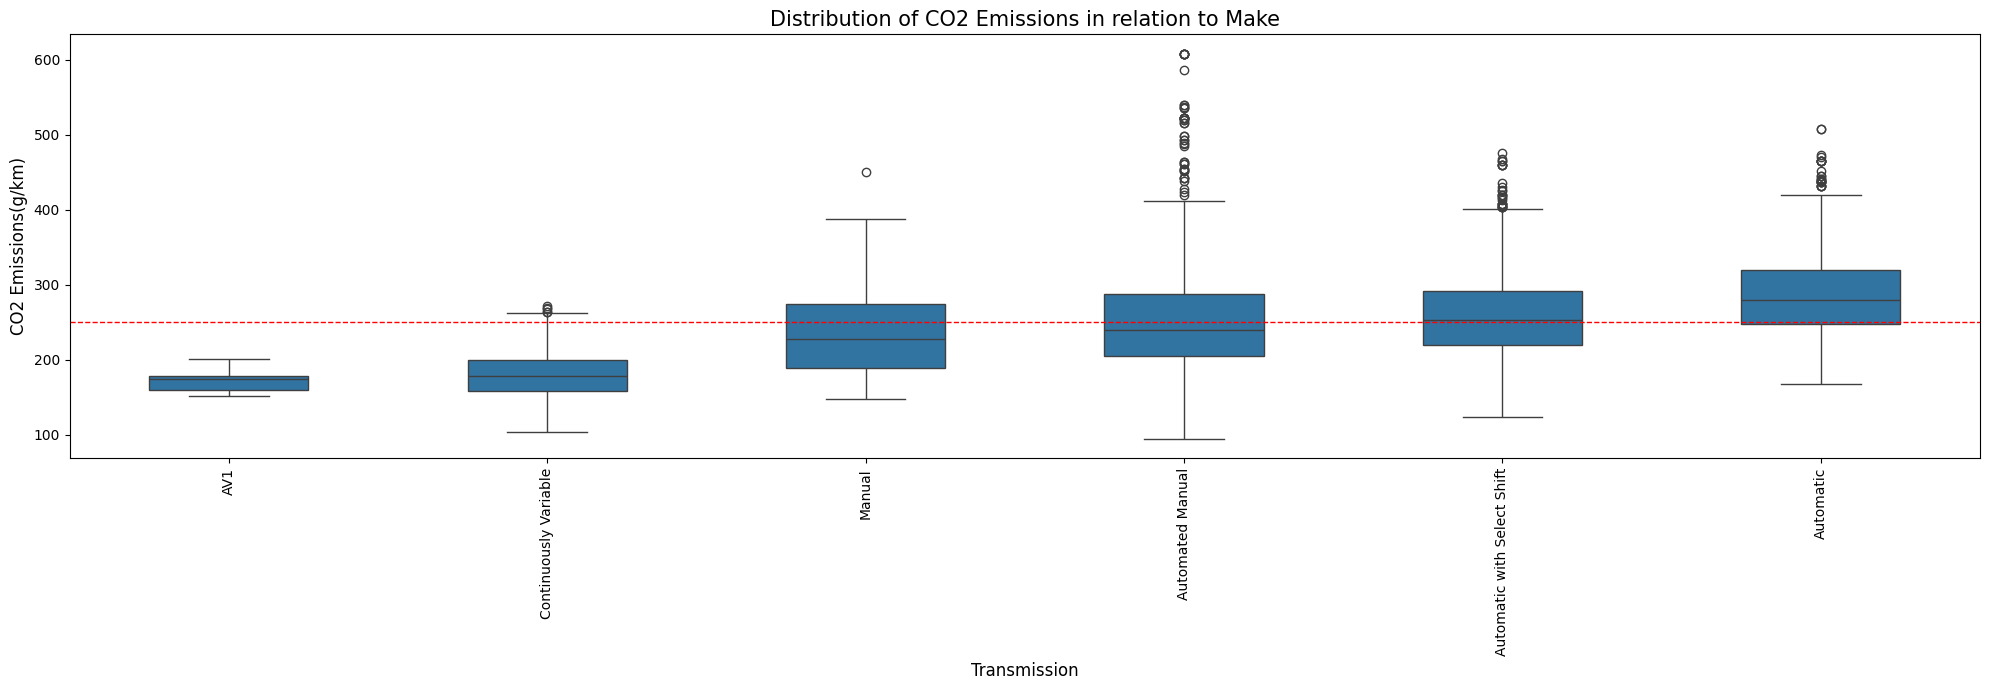

In [50]:
plt.figure(figsize=(20,7))
order = df.groupby("Transmission")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Transmission", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Transmission", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color='green'> CO2 Emissions variation with Fuel Type </font>

In [51]:
df_co2_fuel_type = df.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

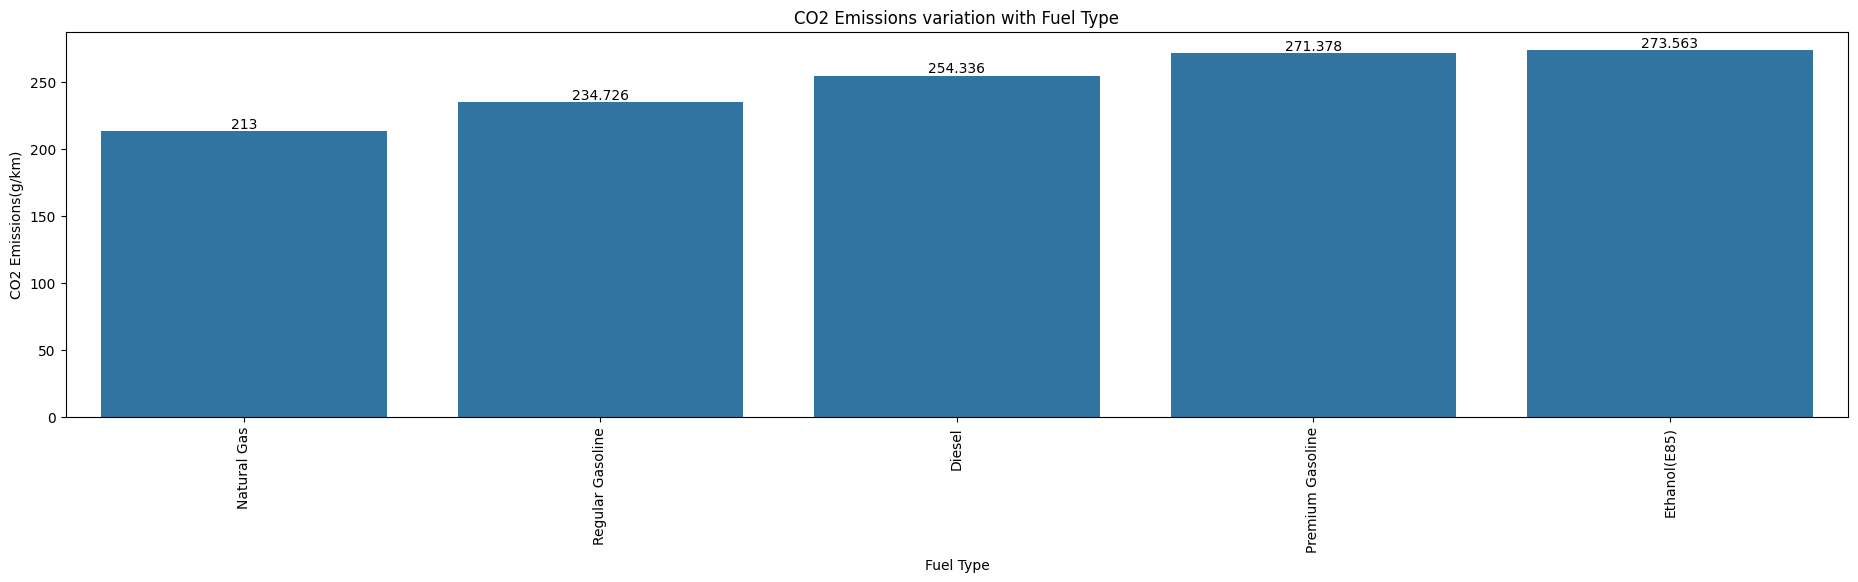

In [52]:
plt.figure(figsize=(23,5))
figure11 = sns.barplot(data=df_co2_fuel_type, x="Fuel Type", y="CO2 Emissions(g/km)", color="C0")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure11.containers[0], fontsize=10)
plt.show()

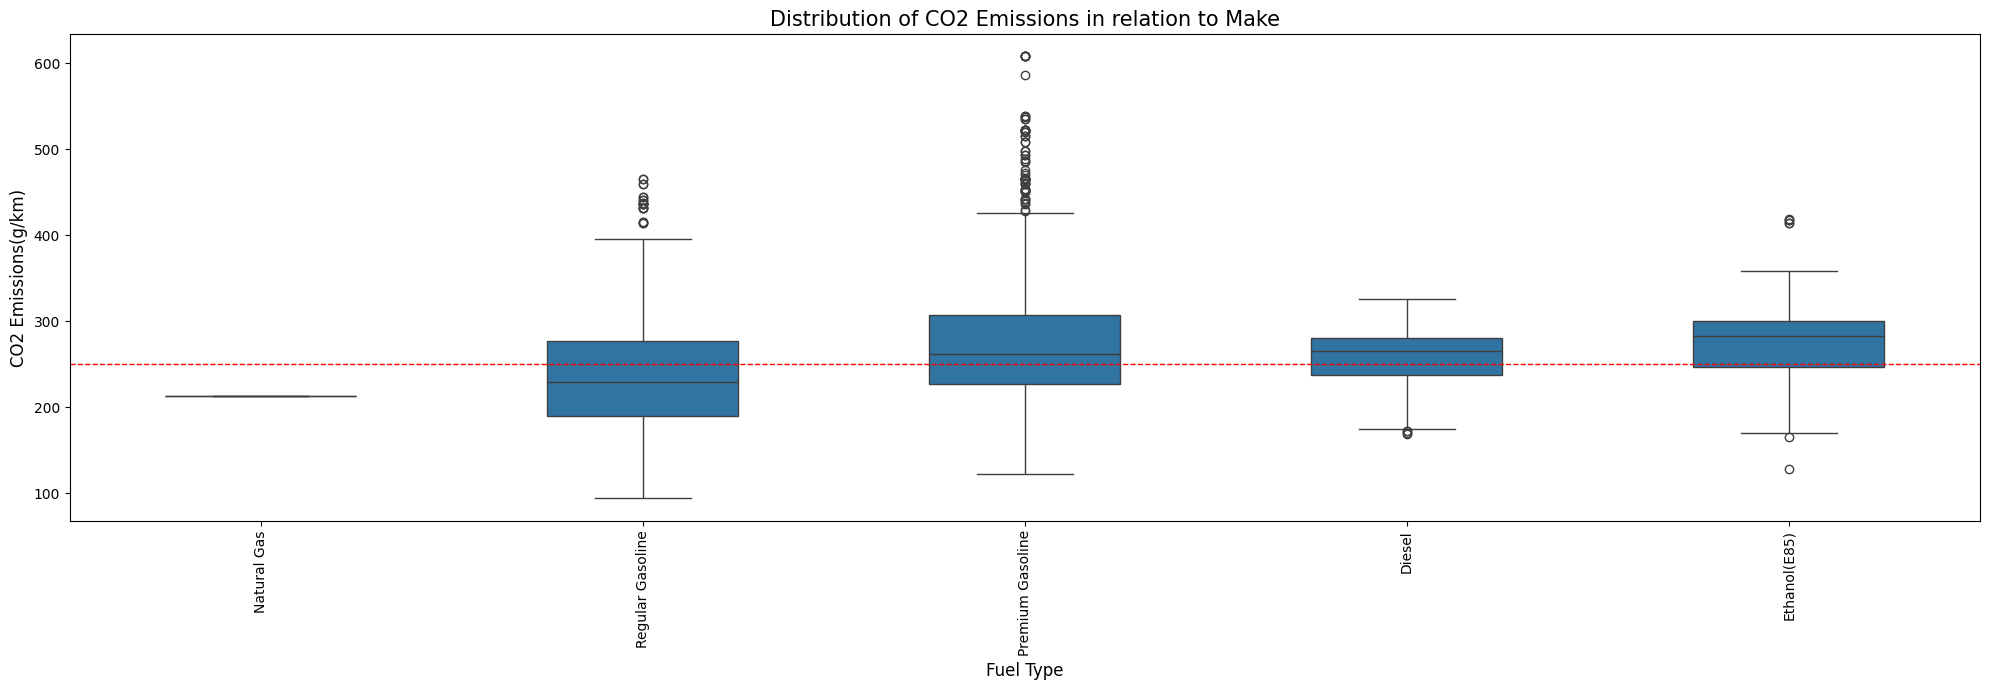

In [53]:
plt.figure(figsize=(20,7))
order = df.groupby("Fuel Type")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Fuel Type", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

### <font color=red>Conclusion Of the EDA </font>
#### 1. There are total 42 types of car brand.
#### 2. There are total 2053 unique car model. These neither can be converted into any dummy variable nor it can be used for analysis. So we can drop this column.
#### 3. There are total 16 types of vehicle class basis on their gross vehicle weight rating (GVWR) and volume index. But there are no data available with exact GVWR or volume index value, so that we can categories the similar vehicle into a same group.
#### 4. The 27 type of transmission has been clubbed into 5 different transmission without taking the number of clutches into account, as they does not affect CO2 emissions.
#### 5. The 5 type of Fuel Types has been renamed so that it has some meaningful interpretation.
#### 6. We have only one data on natural gas. So we cannot predict anything using only one data. That's why we have to drop this row.


## <font color='red'> DATA CLEANING </font>

In [54]:
# Check columns
print(df.columns.tolist())

# Dataset shape
print("Dataset shape:", df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

['Model Year', 'Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'CO2 Rating', 'Smog Rating']
Dataset shape: (11367, 15)

Missing values:
Model Year                             0
Make                                   0
Model                                  0
Vehicle Class                          0
Engine Size(L)                         0
Cylinders                              0
Transmission                           0
Fuel Type                              0
Fuel Consumption City (L/100 km)       0
Fuel Consumption Hwy (L/100 km)        0
Fuel Consumption Comb (L/100 km)       0
Fuel Consumption Comb (mpg)            0
CO2 Emissions(g/km)                    0
CO2 Rating                          1128
Smog Rating                         2234
dtype: int64

Duplicate rows: 8


In [55]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (11359, 15)


In [56]:
# Check fuel type distribution
print(df["Fuel Type"].value_counts())

# Remove Natural Gas
df = df[df["Fuel Type"] != "Natural Gas"].reset_index(drop=True)

print("\nFuel types after removing Natural Gas:")
print(df["Fuel Type"].value_counts())

Fuel Type
Premium Gasoline    5422
Regular Gasoline    5337
Ethanol(E85)         334
Diesel               265
Natural Gas            1
Name: count, dtype: int64

Fuel types after removing Natural Gas:
Fuel Type
Premium Gasoline    5422
Regular Gasoline    5337
Ethanol(E85)         334
Diesel               265
Name: count, dtype: int64


In [57]:
features = [
    "Model Year",
    "Engine Size(L)",
    "Fuel Type",
    "Vehicle Class",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)"
]

target = "CO2 Emissions(g/km)"

# Keep required columns, with Model Year added for time-aware analysis/modeling
df = df[features + [target]]

print(df.columns.tolist())


['Model Year', 'Engine Size(L)', 'Fuel Type', 'Vehicle Class', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']


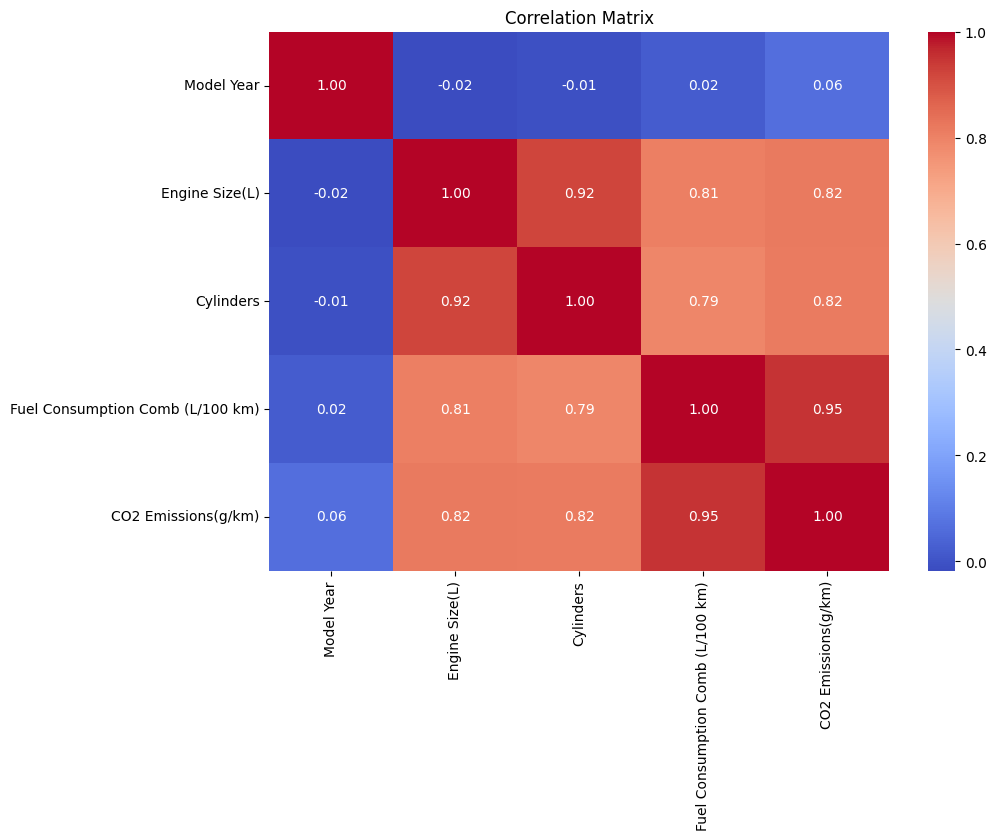

In [58]:
# Numeric columns for correlation
numeric_columns = [
    "Model Year",
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)",
    "CO2 Emissions(g/km)"
]

df_correlation = df[numeric_columns]

# Correlation matrix
correlation = df_correlation.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


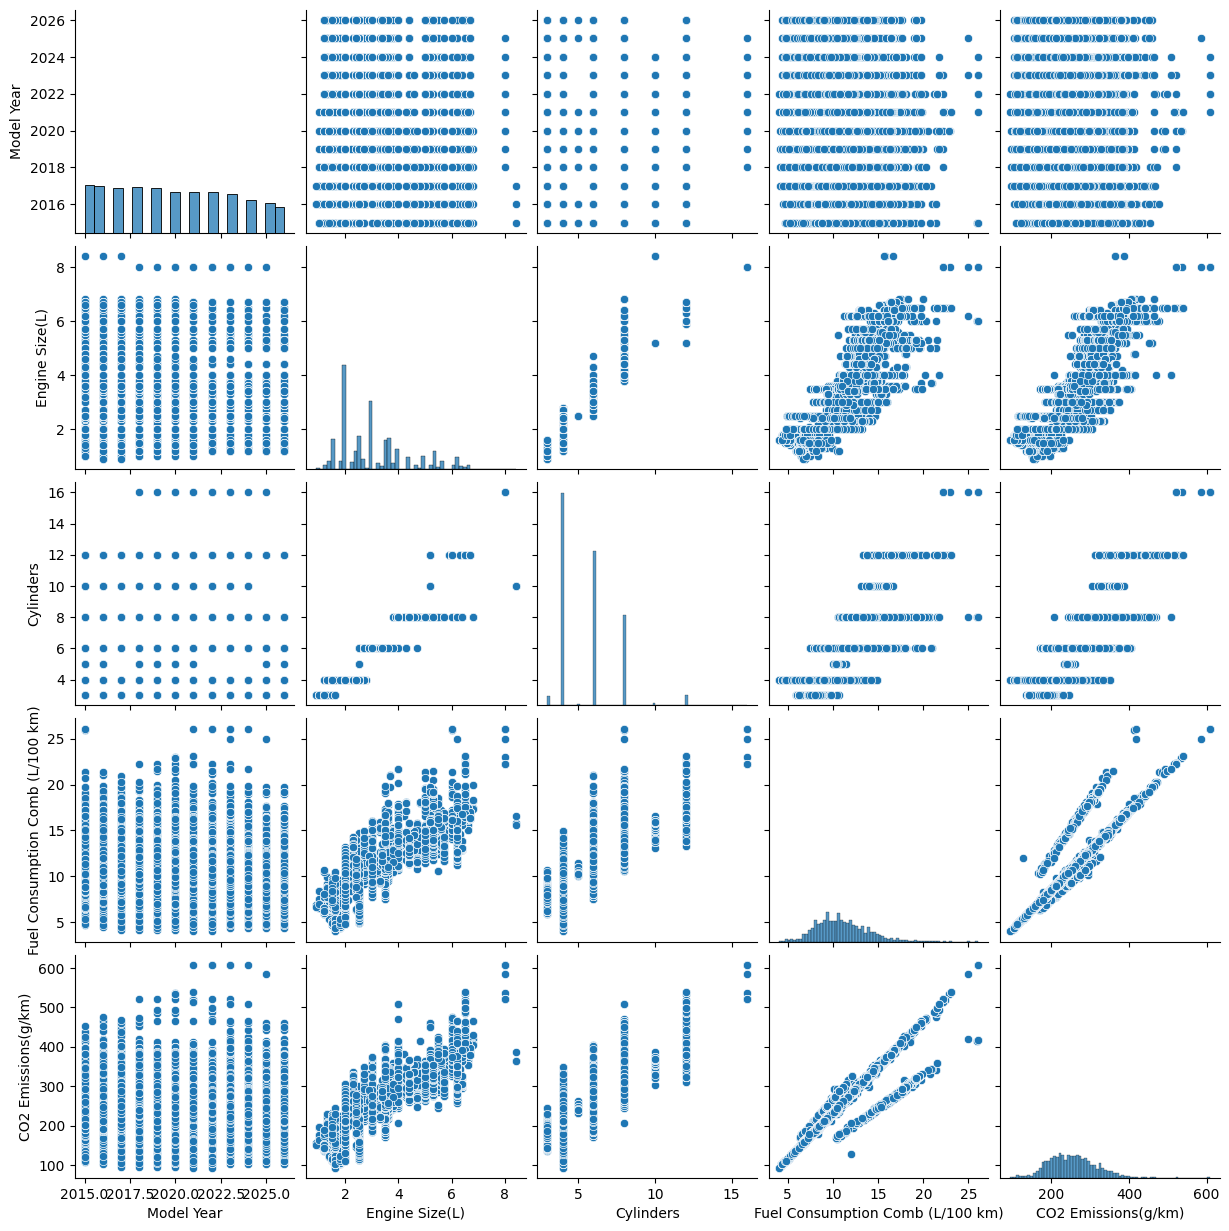

In [59]:
sns.pairplot(df_correlation, plot_kws={'color': 'C0'}, diag_kws={'color': 'C0'})
plt.show()

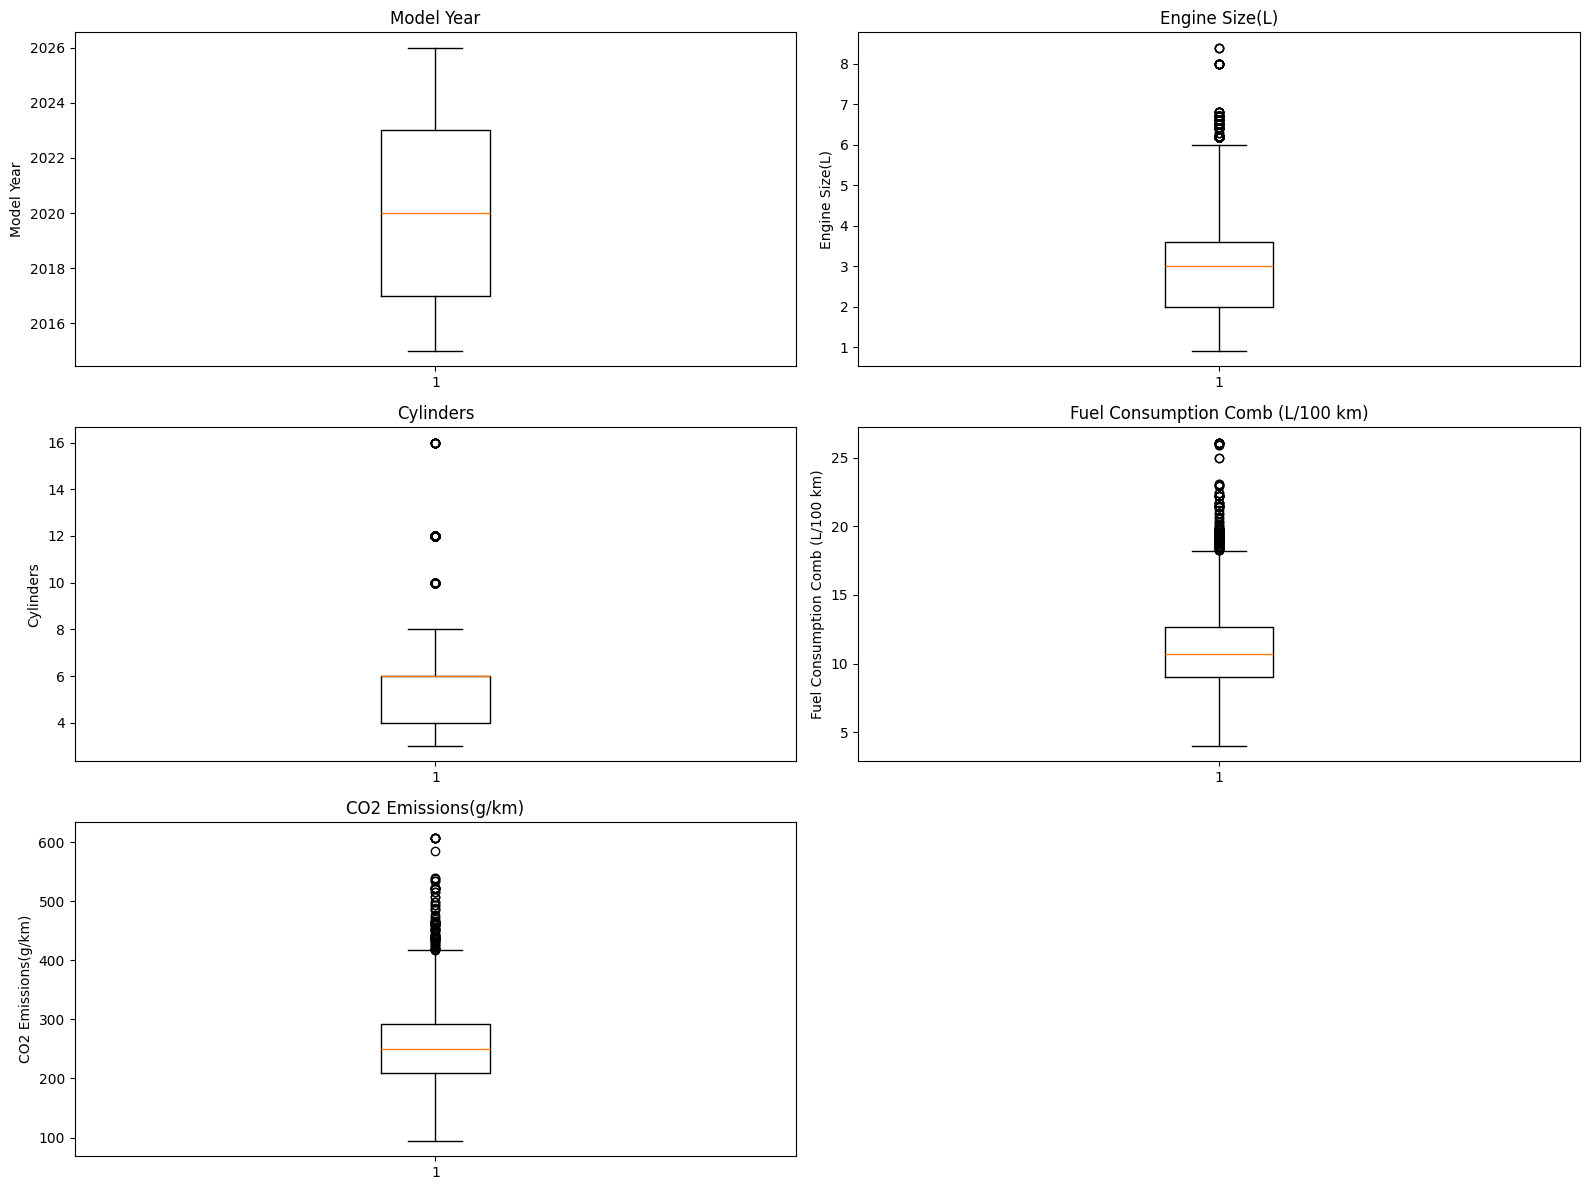

In [60]:
plt.figure(figsize=(16, 12))

for i, column in enumerate(df_correlation.columns):
    plt.subplot(3, 2, i + 1)
    plt.title(column)
    plt.boxplot(df_correlation[column].dropna())
    plt.ylabel(column)

plt.tight_layout()
plt.show()


In [61]:


z = np.abs(stats.zscore(df_correlation))

# Keep rows where all Z-scores are below 3
df_clean = df[(z < 3).all(axis=1)].copy()

print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Outliers removed:", len(df) - len(df_clean))

Original rows: 11358
Rows after removing outliers: 11051
Outliers removed: 307


In [62]:
print(df_clean.head())
print(df_clean.tail())

print("\nDataset information:")
print(df_clean.info())

print("\nSummary statistics:")
print(df_clean.describe().T)

   Model Year  ...  CO2 Emissions(g/km)
0        2015  ...                  191
1        2015  ...                  214
2        2015  ...                  140
3        2015  ...                  255
4        2015  ...                  244

[5 rows x 7 columns]
       Model Year  ...  CO2 Emissions(g/km)
11353        2026  ...                  210
11354        2026  ...                  219
11355        2026  ...                  213
11356        2026  ...                  212
11357        2026  ...                  244

[5 rows x 7 columns]

Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 11051 entries, 0 to 11357
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Model Year                        11051 non-null  int64  
 1   Engine Size(L)                    11051 non-null  float64
 2   Fuel Type                         11051 non-null  object 
 3   Vehicle

In [63]:
print(df_clean["Fuel Type"].value_counts())

Fuel Type
Regular Gasoline    5327
Premium Gasoline    5152
Ethanol(E85)         307
Diesel               265
Name: count, dtype: int64


In [64]:
# Features
X = df_clean[features]

# Target
y = df_clean[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11051, 6)
y shape: (11051,)


In [65]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -----------------------------------------
# Features
# -----------------------------------------

categorical_features = [
    "Fuel Type",
    "Vehicle Class"
]

numeric_features = [
    "Model Year",
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)"
]

# -----------------------------------------
# Preprocessor
# -----------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# -----------------------------------------
# Train / Validation / Test split
# -----------------------------------------

from sklearn.model_selection import train_test_split

X = df_clean[features]
y = df_clean[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# -----------------------------------------
# Fit ONLY on training data
# -----------------------------------------

X_train_encoded = preprocessor.fit_transform(X_train)

# Transform validation and test
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

# Get the correct encoded column names
encoded_columns = preprocessor.get_feature_names_out()

print("Train shape:", X_train_encoded.shape)
print("Validation shape:", X_val_encoded.shape)
print("Test shape:", X_test_encoded.shape)


Train shape: (7735, 23)
Validation shape: (1658, 23)
Test shape: (1658, 23)


In [66]:
# -----------------------------------------
# Create encoded Train DataFrame
# -----------------------------------------

train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns
)

train_encoded[target] = y_train.reset_index(drop=True)
train_encoded["Dataset"] = "Train"


# -----------------------------------------
# Create encoded Validation DataFrame
# -----------------------------------------

val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_columns
)

val_encoded[target] = y_val.reset_index(drop=True)
val_encoded["Dataset"] = "Validation"


# -----------------------------------------
# Create encoded Test DataFrame
# -----------------------------------------

test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns
)

test_encoded[target] = y_test.reset_index(drop=True)
test_encoded["Dataset"] = "Test"

In [67]:
# -----------------------------------------
# Combine all datasets
# -----------------------------------------

all_data = pd.concat(
    [
        train_encoded,
        val_encoded,
        test_encoded
    ],
    ignore_index=True
)

# -----------------------------------------
# Save final processed CSV
# -----------------------------------------

all_data.to_csv(
    "CarbonCo2-2015-2026.csv",
    index=False
)

print("CSV saved successfully!")

print("\nDataset distribution:")
print(all_data["Dataset"].value_counts())

print("\nFinal shape:")
print(all_data.shape)

print("\nFinal columns:")
print(all_data.columns.tolist())


CSV saved successfully!

Dataset distribution:
Dataset
Train         7735
Validation    1658
Test          1658
Name: count, dtype: int64

Final shape:
(11051, 25)

Final columns:
['num__Model Year', 'num__Engine Size(L)', 'num__Cylinders', 'num__Fuel Consumption Comb (L/100 km)', 'cat__Fuel Type_Diesel', 'cat__Fuel Type_Ethanol(E85)', 'cat__Fuel Type_Premium Gasoline', 'cat__Fuel Type_Regular Gasoline', 'cat__Vehicle Class_Compact', 'cat__Vehicle Class_Full-size', 'cat__Vehicle Class_Mid-size', 'cat__Vehicle Class_Minicompact', 'cat__Vehicle Class_Minivan', 'cat__Vehicle Class_Pickup truck: Small', 'cat__Vehicle Class_Pickup truck: Standard', 'cat__Vehicle Class_Special purpose vehicle', 'cat__Vehicle Class_Sport utility vehicle: Small', 'cat__Vehicle Class_Sport utility vehicle: Standard', 'cat__Vehicle Class_Station wagon: Mid-size', 'cat__Vehicle Class_Station wagon: Small', 'cat__Vehicle Class_Subcompact', 'cat__Vehicle Class_Two-seater', 'cat__Vehicle Class_Van: Passenger', 'CO2 

## <font color='red'>Final 2015–2026 Dataset Verification</font>

The final processed dataset keeps the original preprocessing outputs and adds **Model Year** as the time-related feature. The requested file name is **CarbonCo2-2015-2026.csv**.


In [68]:
# Final verification
print("Final processed dataset shape:", all_data.shape)

if "Dataset" in all_data.columns:
    print("\nTrain / Validation / Test:")
    print(all_data["Dataset"].value_counts())

model_year_columns = [c for c in all_data.columns if "Model Year" in c]
print("\nTime-related final column(s):")
print(model_year_columns)

print("\nFirst 5 rows:")
display(all_data.head())

print("\nLast 5 rows:")
display(all_data.tail())


Final processed dataset shape: (11051, 25)

Train / Validation / Test:
Dataset
Train         7735
Validation    1658
Test          1658
Name: count, dtype: int64

Time-related final column(s):
['num__Model Year']

First 5 rows:


,num__Model Year,num__Engine Size(L),num__Cylinders,num__Fuel Consumption Comb (L/100 km),cat__Fuel Type_Diesel,cat__Fuel Type_Ethanol(E85),cat__Fuel Type_Premium Gasoline,cat__Fuel Type_Regular Gasoline,cat__Vehicle Class_Compact,cat__Vehicle Class_Full-size,cat__Vehicle Class_Mid-size,cat__Vehicle Class_Minicompact,cat__Vehicle Class_Minivan,cat__Vehicle Class_Pickup truck: Small,cat__Vehicle Class_Pickup truck: Standard,cat__Vehicle Class_Special purpose vehicle,cat__Vehicle Class_Sport utility vehicle: Small,cat__Vehicle Class_Sport utility vehicle: Standard,cat__Vehicle Class_Station wagon: Mid-size,cat__Vehicle Class_Station wagon: Small,cat__Vehicle Class_Subcompact,cat__Vehicle Class_Two-seater,cat__Vehicle Class_Van: Passenger,CO2 Emissions(g/km),Dataset
0,-1.496095,0.450479,0.355092,0.353626,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,269,Train
1,1.505641,1.098465,1.612997,0.936456,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,311,Train
2,1.505641,1.098465,1.612997,0.936456,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,311,Train
3,-1.195921,-1.250481,-0.902813,-1.433719,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,165,Train
4,-1.195921,-0.521498,-0.902813,0.547903,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,201,Train



Last 5 rows:


,num__Model Year,num__Engine Size(L),num__Cylinders,num__Fuel Consumption Comb (L/100 km),cat__Fuel Type_Diesel,cat__Fuel Type_Ethanol(E85),cat__Fuel Type_Premium Gasoline,cat__Fuel Type_Regular Gasoline,cat__Vehicle Class_Compact,cat__Vehicle Class_Full-size,cat__Vehicle Class_Mid-size,cat__Vehicle Class_Minicompact,cat__Vehicle Class_Minivan,cat__Vehicle Class_Pickup truck: Small,cat__Vehicle Class_Pickup truck: Standard,cat__Vehicle Class_Special purpose vehicle,cat__Vehicle Class_Sport utility vehicle: Small,cat__Vehicle Class_Sport utility vehicle: Standard,cat__Vehicle Class_Station wagon: Mid-size,cat__Vehicle Class_Station wagon: Small,cat__Vehicle Class_Subcompact,cat__Vehicle Class_Two-seater,cat__Vehicle Class_Van: Passenger,CO2 Emissions(g/km),Dataset
11046,0.605121,1.827448,1.612997,1.208444,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,327,Test
11047,-0.895748,-0.845491,-0.902813,-0.773178,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206,Test
11048,0.004773,-1.250481,-0.902813,-1.317153,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,172,Test
11049,0.605121,1.827448,1.612997,1.558142,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347,Test
11050,0.004773,0.774472,1.612997,1.091878,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,315,Test
